# Exploratory Analysis of Iran Mercantile Exchange Physical Bitumen

Objective: identify the leading producers, product grades, market structure, and preliminary benchmark candidates before matching the physical market to the official certificate specification. All transformations are performed in memory; this notebook does not write derived datasets or external outputs.

> Statistical market dominance does not by itself determine the appropriate certificate underlying. Technical specification, delivery location, unit, contract terms, and settlement conditions must also match.

In [1]:
from pathlib import Path
import re
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from IPython.display import display

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
warnings.filterwarnings('ignore', category=FutureWarning)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (12, 6), 'axes.unicode_minus': False})

## 1. Read-only ingestion and data audit

In [2]:
def find_root(start):
    for path in (start, *start.parents):
        if (path / 'commodity' / 'bitumen').is_dir():
            return path
    raise FileNotFoundError('Workspace root not found')

ROOT = find_root(Path.cwd().resolve())
DATA_PATH = ROOT / 'commodity/bitumen/data/raw/physical/bitumen_physical_raw.csv'
required = {'GoodsName', 'Symbol', 'ProducerName', 'ContractType', 'Price', 'Quantity', 'TotalPrice', 'date', 'Warehouse', 'ArzehKonandeh', 'Currency', 'Unit', 'Talar', 'Tasvieh'}
raw = pd.read_csv(DATA_PATH, encoding='utf-8-sig', low_memory=False)
assert not required.difference(raw.columns), f'Missing: {sorted(required.difference(raw.columns))}'
for col in ['MinPrice', 'Price', 'MaxPrice', 'arze', 'ArzeBasePrice', 'taghaza', 'Quantity', 'TotalPrice']:
    raw[col] = pd.to_numeric(raw[col], errors='coerce')
parts = raw['date'].astype('string').str.replace('-', '/', regex=False).str.extract(r'^(\d{4})/(\d{1,2})/(\d{1,2})$')
raw['jalali_year'] = pd.to_numeric(parts[0], errors='coerce').astype('Int64')
raw['jalali_month_num'] = pd.to_numeric(parts[1], errors='coerce').astype('Int64')
raw['jalali_date'] = parts[0] + '/' + parts[1].str.zfill(2) + '/' + parts[2].str.zfill(2)
raw['jalali_month'] = parts[0] + '/' + parts[1].str.zfill(2)
raw['month_index'] = raw['jalali_year'] * 12 + raw['jalali_month_num'] - 1
quality = pd.Series({
    'rows': len(raw), 'columns': raw.shape[1], 'duplicate_full_rows': raw.duplicated().sum(),
    'invalid_dates': raw['jalali_date'].isna().sum(), 'missing_producer': raw['ProducerName'].isna().sum(),
    'nonpositive_quantity': raw['Quantity'].fillna(0).le(0).sum(),
    'positive_quantity_nonpositive_price': (raw['Quantity'].gt(0) & raw['Price'].fillna(0).le(0)).sum(),
    'positive_quantity_nonpositive_value': (raw['Quantity'].gt(0) & raw['TotalPrice'].fillna(0).le(0)).sum(),
})
print(DATA_PATH.relative_to(ROOT))
display(quality.to_frame('count'))
display(raw.head(3))

commodity\bitumen\data\raw\physical\bitumen_physical_raw.csv


,count
rows,47085
columns,41
duplicate_full_rows,0
invalid_dates,0
missing_producer,0
nonpositive_quantity,22922
positive_quantity_nonpositive_price,0
positive_quantity_nonpositive_value,0


,GoodsName,Symbol,ProducerName,ContractType,MinPrice,Price,MaxPrice,arze,ArzeBasePrice,arzeMinPrice,taghaza,taghazavoroudi,taghazaMaxPrice,Quantity,TotalPrice,date,DeliveryDate,Warehouse,ArzehKonandeh,SettlementDate,Category,xTalarReportPK,bArzehRadifTarSarresid,cBrokerSpcName,ModeDescription,MethodDescription,MinPrice1,Price1,Currency,Unit,arzehPk,Talar,PacketName,Tasvieh,fetched_at_utc,source_url,jalali_year,jalali_month_num,jalali_date,jalali_month,month_index
0,قیر 6070,JRC-BI6070-00,نفت جی,نقدی (مچینگ),"4,090.00","4,090.00","4,090.00",0.00,"4,150.00",0,"1,400.00",0,"4,110.00","1,400.00","5,726,000.00",1387/06/02,NaN,انبار کارخانه,پالایش نفت جی,NaN,3-16-49,0,NaN,خبرگان سهام,عمده,عادي,"4,090.00","4,090.00",ریال,تن,10112,تالار پتروشیمی,NaN,NaN,2026-08-03T10:11:28+00:00,https://www.ime.co.ir/subsystems/ime/services/...,1387,6,1387/06/02,1387/06,16649
1,قیر 6070,JRC-BI6070-00,نفت جی,نقدی,"4,090.00","4,103.00","4,110.00","4,510.00","4,150.00",0,"4,360.00",0,"4,110.00","4,160.00","17,069,600.00",1387/06/02,NaN,انبار کارخانه,پالایش نفت جی,NaN,3-16-49,4,NaN,خبرگان سهام,عمده,عادي,"4,090.00","4,103.00",ریال,تن,10112,تالار پتروشیمی,NaN,NaN,2026-08-03T10:11:28+00:00,https://www.ime.co.ir/subsystems/ime/services/...,1387,6,1387/06/02,1387/06,16649
2,قیر 85100,JRC-BI85100-00,نفت جی,نقدی (مچینگ),"4,090.00","4,090.00","4,090.00",0.00,"4,150.00",0,500.00,0,"4,110.00",500.00,"2,045,000.00",1387/06/02,NaN,انبار کارخانه,پالایش نفت جی,NaN,3-16-49,0,NaN,خبرگان سهام,عمده,عادي,"4,090.00","4,090.00",ریال,تن,10113,تالار پتروشیمی,NaN,NaN,2026-08-03T10:11:28+00:00,https://www.ime.co.ir/subsystems/ime/services/...,1387,6,1387/06/02,1387/06,16649


## 2. Temporary normalization and analytical scope

Untraded offers remain in the raw dataset. Volume and price analyses use only observations with positive traded quantity, price, and value. Producer aliases are not manually consolidated at this stage.

In [3]:
def normalize_fa(value):
    if pd.isna(value): return pd.NA
    text = str(value).replace('ي', 'ی').replace('ى', 'ی').replace('ك', 'ک').replace('ۀ', 'ه').replace('ة', 'ه').replace('ـ', '')
    text = re.sub(r'[\u200c\u200f\u202a-\u202e]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

text_cols = ['GoodsName', 'Symbol', 'ProducerName', 'ContractType', 'Warehouse', 'ArzehKonandeh', 'ModeDescription', 'MethodDescription', 'Currency', 'Unit', 'Talar', 'Tasvieh']
for col in text_cols: raw[col + '_clean'] = raw[col].map(normalize_fa)
trades = raw.loc[raw['Quantity'].gt(0) & raw['Price'].gt(0) & raw['TotalPrice'].gt(0)].copy()
print(f'Raw rows: {len(raw):,} | Positive analytical trades: {len(trades):,}')
print(f"Coverage: {raw['jalali_date'].min()} to {raw['jalali_date'].max()}")
audit = []
for col in ['GoodsName_clean', 'ProducerName_clean', 'ArzehKonandeh_clean', 'ContractType_clean', 'Unit_clean', 'Currency_clean', 'Talar_clean', 'Tasvieh_clean']:
    audit.append({'field': col, 'unique_all': raw[col].nunique(), 'unique_traded': trades[col].nunique(), 'missing_traded': trades[col].isna().sum()})
display(pd.DataFrame(audit).set_index('field'))
for col in ['Unit_clean', 'Currency_clean', 'Talar_clean', 'ContractType_clean', 'Tasvieh_clean']:
    print('\n', col)
    display(trades.groupby(col, dropna=False).agg(rows=('Quantity', 'size'), volume=('Quantity', 'sum'), value=('TotalPrice', 'sum')).sort_values('volume', ascending=False).head(20))

Raw rows: 47,085 | Positive analytical trades: 24,163
Coverage: 1387/06/02 to 1405/05/24


,unique_all,unique_traded,missing_traded
field,,,
GoodsName_clean,51,37,0
ProducerName_clean,160,123,0
ArzehKonandeh_clean,147,109,0
ContractType_clean,8,8,0
Unit_clean,2,2,0
Currency_clean,2,2,0
Talar_clean,5,4,0
Tasvieh_clean,3,3,9565



 Unit_clean


,rows,volume,value
Unit_clean,,,
تن,24161,"21,237,615.00","482,619,831,898.33"
بشکه,2,"1,000.00","729,000.00"



 Currency_clean


...

,rows,volume,value
Talar_clean,,,
تالار پتروشیمی,6267,"7,724,425.00","28,205,589,387.51"
تالار فرآورده های نفتی,10595,"7,002,048.00","381,592,077,173.82"
تالار چند کالایی,7291,"6,507,262.00","65,566,935,937.00"
تالار صنعتی,10,"4,880.00","7,255,958,400.00"



 ContractType_clean


,rows,volume,value
ContractType_clean,,,
نقدی,18034,"17,449,891.00","282,407,519,679.99"
نقدی (مچینگ),4089,"2,007,091.50","42,665,139,619.72"
نسیه,988,"698,206.00","118,264,879,379.10"
سلف,242,"531,489.50","17,249,390,182.00"
نقدی ($),109,"231,760.00","94,615.65"
نسیه (مچینگ),543,"141,327.00","14,257,340,476.00"
نقدی ($ مچینگ),108,"139,680.00","47,245.86"
سلف (مچینگ),50,"39,170.00","7,776,149,700.00"



 Tasvieh_clean


,rows,volume,value
Tasvieh_clean,,,
NaN,9565,"10,646,511.00","52,837,921,135.51"
اعتباری,5484,"5,396,337.00","112,148,744,712.99"
نقدی / اعتباری,7313,"4,519,244.00","275,635,952,683.63"
نقدی,1801,"676,523.00","41,997,942,366.19"


## 3. Exploratory taxonomy of product family, grade, and market

These classification rules are provisional. The review table exposes every source product label and assigned category so that rule errors can be corrected before any benchmark is constructed.

In [4]:
def classify(goods):
    text = normalize_fa(goods) or ''
    compact = re.sub(r'[\s/_-]+', '', text).upper()
    if 'آند آلومینیوم' in text: family = 'anode_material'
    elif 'امولسیون' in text or 'امولسیونی' in text: family = 'emulsion'
    elif 'پلیمری' in text: family = 'polymer_modified'
    elif re.search(r'\bPG\s*\d', text, re.I): family = 'performance_grade'
    elif re.search(r'\b(?:MC|RC|SC)\s*\d', text, re.I): family = 'cutback'
    elif re.search(r'\d', text): family = 'penetration_or_numeric'
    else: family = 'unclassified'
    grade = pd.NA
    for pattern in [r'\b(PG)\s*(\d{4})\b', r'\b(MC|RC|SC|CMS|CQS|CRS|CSS)\s*[- ]?([0-9]+H?)\b', r'\b(SPB)\b']:
        match = re.search(pattern, text, re.I)
        if match:
            grade = ''.join(x for x in match.groups() if x).upper(); break
    if pd.isna(grade):
        match = re.search(r'(?<![A-Z])([0-9]{4,6})(?![0-9])', compact)
        if match: grade = match.group(1)
    if pd.isna(grade) and family == 'emulsion':
        grade = 'slow_setting' if 'دیرشکن' in text else ('rapid_setting' if 'زودشکن' in text else pd.NA)
    return family, grade

raw[['bitumen_family', 'grade']] = pd.DataFrame(raw['GoodsName_clean'].map(classify).tolist(), index=raw.index)
raw['market_segment'] = np.where(raw['GoodsName_clean'].str.contains('صادرات', na=False) | raw['Talar_clean'].str.contains('صادرات', na=False), 'export', 'domestic_or_unspecified')
trades = raw.loc[raw['Quantity'].gt(0) & raw['Price'].gt(0) & raw['TotalPrice'].gt(0)].copy()
taxonomy = (raw.groupby(['GoodsName_clean', 'bitumen_family', 'grade', 'market_segment'], dropna=False).agg(rows=('Quantity', 'size'), traded_rows=('Quantity', lambda s: s.gt(0).sum()), volume=('Quantity', lambda s: s.where(s.gt(0), 0).sum())).sort_values('volume', ascending=False))
display(taxonomy)
print('Labels requiring manual review:')
display(taxonomy.reset_index().query("bitumen_family == 'unclassified' or grade.isna()", engine='python'))

,,,,rows,traded_rows,volume
GoodsName_clean,bitumen_family,grade,market_segment,,,
قیر 6070,penetration_or_numeric,6070,domestic_or_unspecified,17435,12156,"13,457,978.00"
قیر 85100,penetration_or_numeric,85100,domestic_or_unspecified,6454,2888,"2,435,500.00"
قیر PG6422,performance_grade,PG6422,domestic_or_unspecified,3715,1919,"2,079,371.00"
قیر MC250,cutback,MC250,domestic_or_unspecified,7698,4181,"854,156.00"
قیر PG6416,performance_grade,PG6416,domestic_or_unspecified,1161,567,"461,510.00"
قیر PG7010,performance_grade,PG7010,domestic_or_unspecified,1951,670,"461,252.00"
قیر 6070 - صادراتی,penetration_or_numeric,6070,export,304,174,"331,880.00"
قیر PG5822,performance_grade,PG5822,domestic_or_unspecified,2204,540,"299,708.00"
قیر MC160,cutback,MC160,domestic_or_unspecified,23,21,"256,000.00"


Labels requiring manual review:


,GoodsName_clean,bitumen_family,grade,market_segment,rows,traded_rows,volume
18,قیر آند آلومینیوم,anode_material,NaN,domestic_or_unspecified,10,10,"4,880.00"


## 4. Producers: traded volume, value, and historical continuity

,volume,value,trades,active_days,active_months,first_date,last_date,goods_labels,grades,symbols,span_months,month_coverage,volume_share,value_share,mean_trade_volume
ProducerName_clean,,,,,,,,,,,,,,,
نفت جی,"6,978,267.00","73,129,323,809.98",6421,1974,193,1387/06/02,1404/11/08,14,12,24,210,0.92,0.33,0.15,"1,086.79"
نفت پاسارگاد تهران,"4,249,556.00","81,785,447,160.26",3581,1859,198,1388/06/02,1405/05/19,19,17,22,204,0.97,0.20,0.17,"1,186.70"
نفت پاسارگاد اراک,"2,572,124.00","65,988,023,053.37",2916,1798,211,1387/06/02,1405/05/24,11,10,19,216,0.98,0.12,0.14,882.07
نفت پاسارگاد شیراز,"1,730,802.00","25,454,851,580.99",2396,1384,188,1388/06/02,1404/12/04,18,17,21,199,0.94,0.08,0.05,722.37
نفت پاسارگاد تبریز,"1,008,256.00","15,878,612,015.70",1201,937,162,1388/06/02,1405/05/12,9,8,10,204,0.79,0.05,0.03,839.51
نفت پاسارگاد بندرعباس,"862,656.00","13,147,577,412.60",1380,912,173,1388/06/03,1405/02/15,9,9,10,201,0.86,0.04,0.03,625.11
نفت پاسارگاد آبادان,"849,079.00","14,737,796,149.31",2020,1222,186,1388/06/02,1404/11/08,9,9,11,198,0.94,0.04,0.03,420.34
نفت پاسارگاد -تهران,"525,347.00","1,761,241,313.20",368,202,13,1387/06/02,1388/06/18,4,2,10,13,1.00,0.02,0.00,"1,427.57"
نفت پاسارگاد - شیراز,"422,210.00","1,472,347,400.00",555,218,12,1387/06/02,1388/05/28,3,2,9,12,1.00,0.02,0.00,760.74


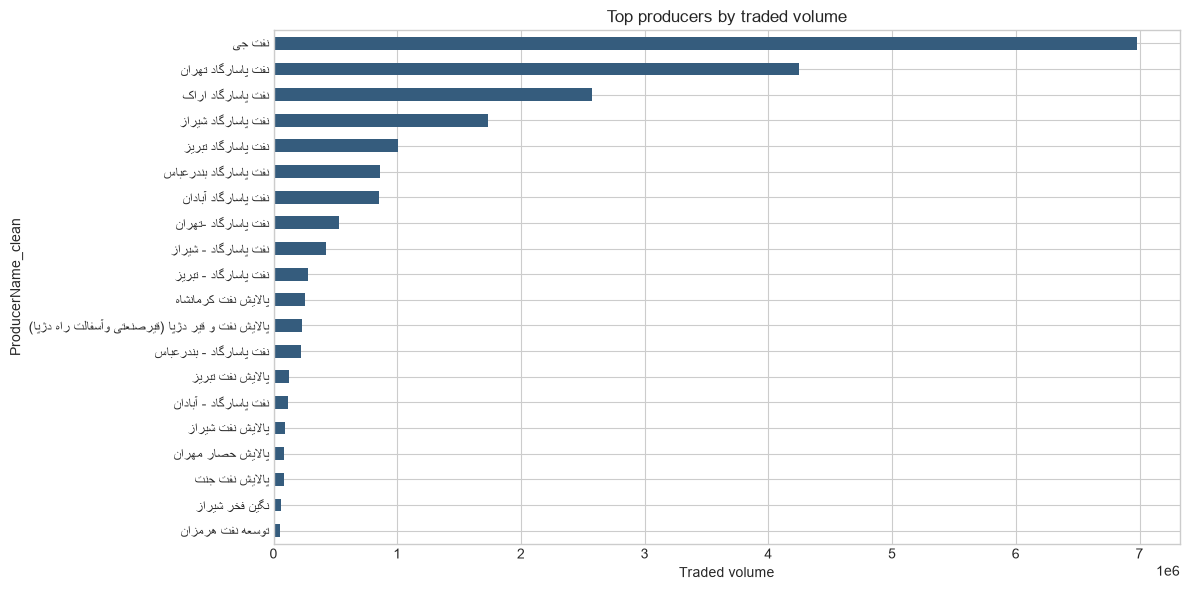

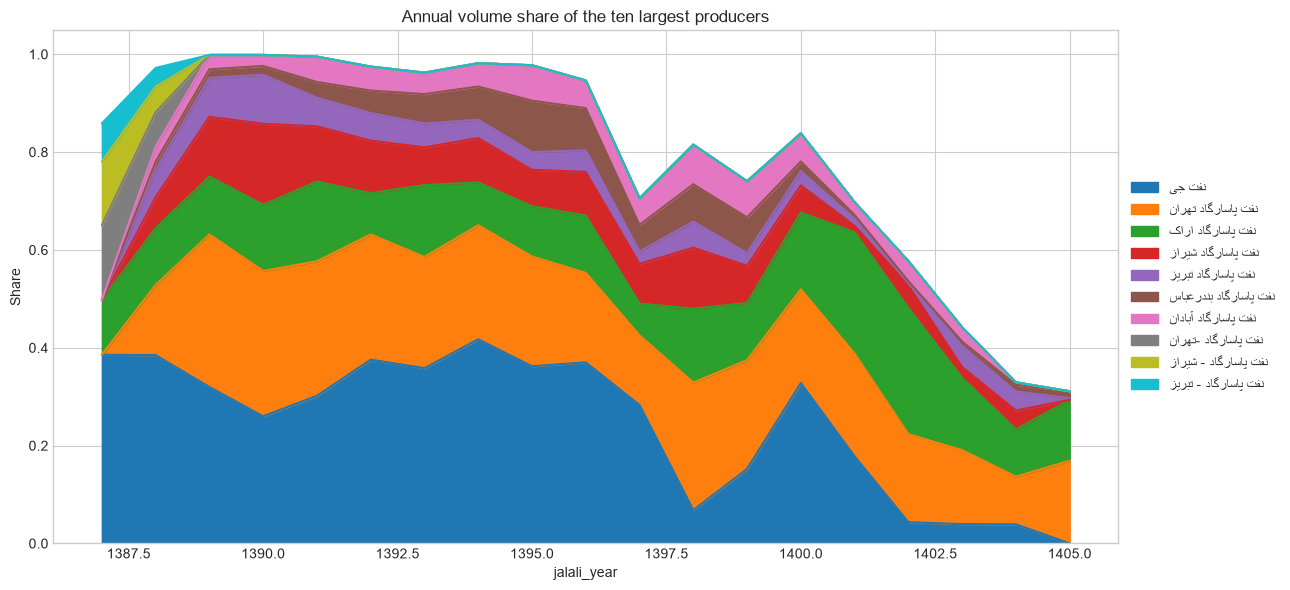

In [5]:
def entity_metrics(frame, groups):
    out = frame.groupby(groups, dropna=False).agg(volume=('Quantity', 'sum'), value=('TotalPrice', 'sum'), trades=('Quantity', 'size'), active_days=('jalali_date', 'nunique'), active_months=('jalali_month', 'nunique'), first_date=('jalali_date', 'min'), last_date=('jalali_date', 'max'), first_idx=('month_index', 'min'), last_idx=('month_index', 'max'), goods_labels=('GoodsName_clean', 'nunique'), grades=('grade', 'nunique'), symbols=('Symbol_clean', 'nunique'))
    out['span_months'] = out['last_idx'] - out['first_idx'] + 1
    out['month_coverage'] = out['active_months'] / out['span_months']
    out['volume_share'] = out['volume'] / out['volume'].sum()
    out['value_share'] = out['value'] / out['value'].sum()
    out['mean_trade_volume'] = out['volume'] / out['trades']
    return out.drop(columns=['first_idx', 'last_idx']).sort_values('volume', ascending=False)

producer_summary = entity_metrics(trades, ['ProducerName_clean'])
display(producer_summary.head(40))
producer_summary.head(20).sort_values('volume')['volume'].plot.barh(color='#355C7D')
plt.title('Top producers by traded volume'); plt.xlabel('Traded volume'); plt.tight_layout(); plt.show()

producer_year = trades.pivot_table(index='jalali_year', columns='ProducerName_clean', values='Quantity', aggfunc='sum', fill_value=0)
leaders = producer_summary.head(10).index
producer_year.div(producer_year.sum(axis=1), axis=0).reindex(columns=leaders).plot.area(figsize=(13, 6))
plt.title('Annual volume share of the ten largest producers'); plt.ylabel('Share'); plt.legend(loc='center left', bbox_to_anchor=(1, .5)); plt.tight_layout(); plt.show()

Producer versus supplier — no aliases are merged yet:


,,volume,trades,first_date,last_date
ProducerName_clean,ArzehKonandeh_clean,,,,
نفت جی,پالایش نفت جی,"6,977,667.00",6420,1387/06/02,1404/11/08
نفت پاسارگاد تهران,نفت پاسارگاد,"4,249,214.00",3580,1388/06/02,1405/05/19
نفت پاسارگاد اراک,نفت پاسارگاد,"1,945,901.00",2452,1389/03/16,1405/05/24
نفت پاسارگاد شیراز,نفت پاسارگاد,"1,488,563.00",2187,1389/03/16,1404/12/04
نفت پاسارگاد تبریز,نفت پاسارگاد,"807,981.00",1095,1389/03/17,1405/05/12
نفت پاسارگاد بندرعباس,نفت پاسارگاد,"804,729.00",1322,1389/03/23,1405/02/15
نفت پاسارگاد آبادان,نفت پاسارگاد,"731,570.00",1881,1389/03/16,1404/11/08
نفت پاسارگاد اراک,نفت پاسارگاد - اراک,"626,223.00",464,1387/06/02,1389/03/12
نفت پاسارگاد -تهران,نفت پاسارگاد,"525,347.00",368,1387/06/02,1388/06/18


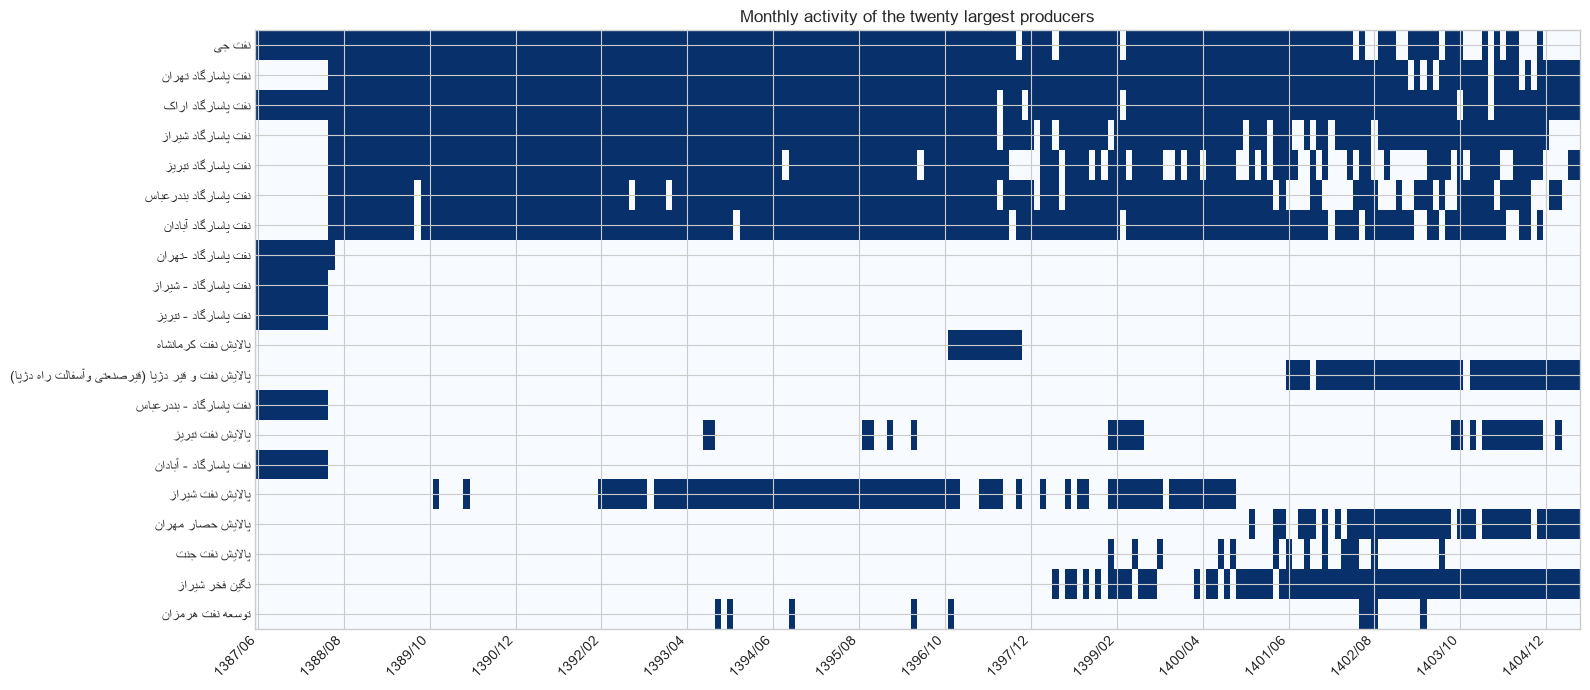

In [6]:
producer_supplier = (trades.groupby(['ProducerName_clean', 'ArzehKonandeh_clean'], dropna=False).agg(volume=('Quantity', 'sum'), trades=('Quantity', 'size'), first_date=('jalali_date', 'min'), last_date=('jalali_date', 'max')).sort_values('volume', ascending=False))
print('Producer versus supplier — no aliases are merged yet:')
display(producer_supplier.head(100))

activity = trades.assign(active=1).pivot_table(index='ProducerName_clean', columns='jalali_month', values='active', aggfunc='max', fill_value=0).reindex(index=producer_summary.head(20).index)
fig, ax = plt.subplots(figsize=(16, 7)); ax.imshow(activity, aspect='auto', interpolation='nearest', cmap='Blues')
ax.set_yticks(range(len(activity)), labels=activity.index); step = max(1, len(activity.columns) // 15); ticks = list(range(0, len(activity.columns), step)); ax.set_xticks(ticks, labels=[activity.columns[i] for i in ticks], rotation=45, ha='right')
ax.set_title('Monthly activity of the twenty largest producers'); plt.tight_layout(); plt.show()

## 5. Grades, domestic/export segments, and the producer–grade matrix

volume  \
bitumen_family         grade         market_segment                          
penetration_or_numeric 6070          domestic_or_unspecified 13,457,978.00   
                       85100         domestic_or_unspecified  2,435,500.00   
performance_grade      PG6422        domestic_or_unspecified  2,079,371.00   
cutback                MC250         domestic_or_unspecified    854,156.00   
performance_grade      PG6416        domestic_or_unspecified    461,510.00   
                       PG7010        domestic_or_unspecified    461,252.00   
penetration_or_numeric 6070          export                     331,880.00   
performance_grade      PG5822        domestic_or_unspecified    299,708.00   
cutback                MC160         domestic_or_unspecified    256,000.00   
performance_grade      PG6410        domestic_or_unspecified    180,889.00   
penetration_or_numeric 4050          domestic_or_unspecified    141,111.00   
                       200300        domestic_or_unspecified     80,644.00   
performance_grade      PG7016        domestic_or_unspecified     67,366.00   
penetration_or_numeric 85100         export                      36,400.00   
performance_grade      PG7610        domestic_or_unspecified     30,979.00   
                       PG5816        domestic_or_unspecified     26,490.00   
emulsion               CRS1          domestic_or_unspecified      8,440.00   
                       rapid_setting domestic_or_unspecified      6,260.00   
anode_material         NaN           domestic_or_unspecified      4,880.00   
emulsion               6070          domestic_or_unspecified      4,242.00   
                       CSS1          domestic_or_unspecified      2,914.00   
performance_grade      PG5828        domestic_or_unspecified      2,700.00   
emulsion               slow_setting  domestic_or_unspecified      1,930.00   
                       CRS2          domestic_or_unspecified      1,180.00   
polymer_modified       PG6422        domestic_or_unspecified      1,069.00   
                       85100         domestic_or_unspecified      1,050.00   
penetration_or_numeric 9015          domestic_or_unspecified      1,000.00   
                       100120        domestic_or_unspecified        500.00   
emulsion               CMS2          domestic_or_unspecified        360.00   
                       85100         domestic_or_unspecified        350.00   
                       CSS1H         domestic_or_unspecified        161.00   
cutback                MC70          domestic_or_unspecified         80.00   
                       MC30          domestic_or_unspecified         60.00   
                       MC3000        domestic_or_unspecified         60.00   
emulsion               6070          export                          50.00   
performance_grade      PG5210        domestic_or_unspecified         50.00   
polymer_modified       7622          domestic_or_unspecified         45.00   

                                                                          value  \
bitumen_family         grade         market_segment                               
penetration_or_numeric 6070          domestic_or_unspecified 280,643,987,499.03   
                       85100         domestic_or_unspecified  18,586,115,955.80   
performance_grade      PG6422        domestic_or_unspecified  92,959,611,828.38   
cutback                MC250         domestic_or_unspecified  12,169,480,752.18   
performance_grade      PG6416        domestic_or_unspecified  10,999,589,516.02   
                       PG7010        domestic_or_unspecified  17,302,160,099.37   
penetration_or_numeric 6070          export                          126,303.95   
performance_grade      PG5822        domestic_or_unspecified   9,184,434,438.96   
cutback                MC160         domestic_or_unspecified   6,837,256,000.00   
performance_grade      PG6410        domestic_or_unspecified   1,662,750,680.46   
penetration_or_numeric 4050  

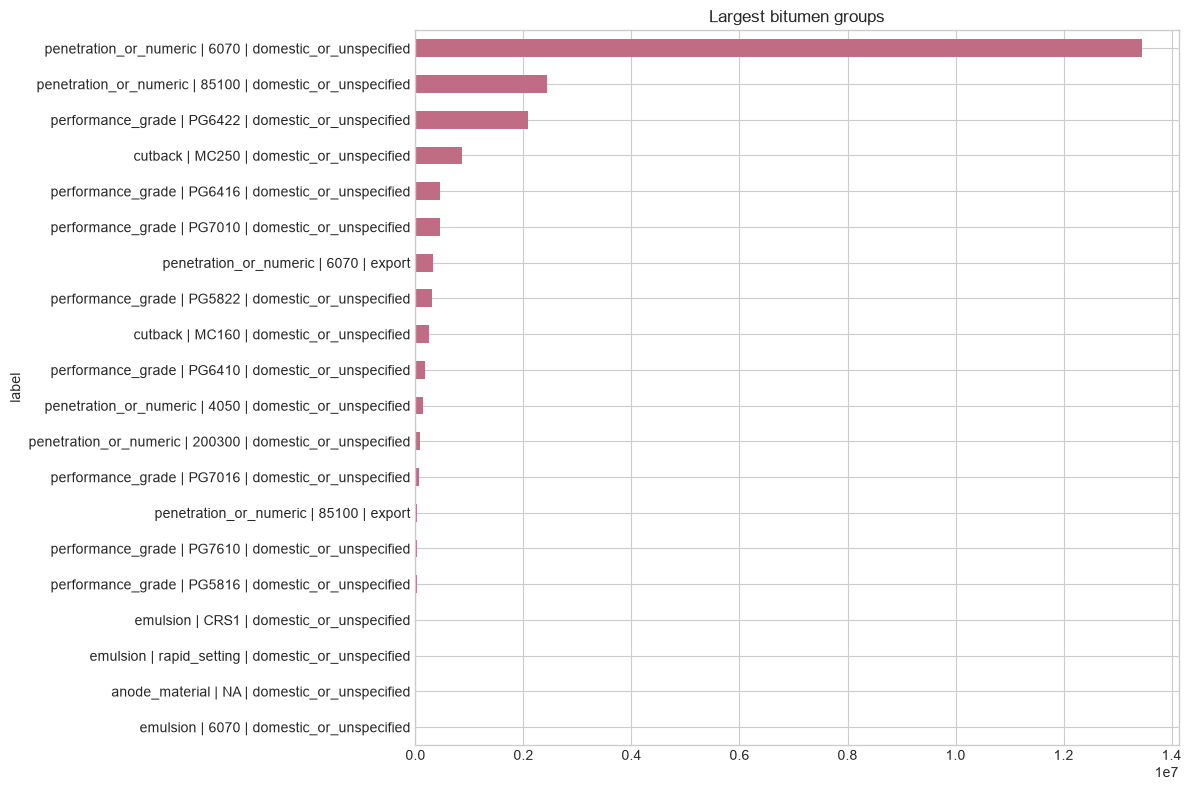

In [7]:
grade_groups = ['bitumen_family', 'grade', 'market_segment']
grade_summary = entity_metrics(trades, grade_groups)
grade_summary['producer_count'] = trades.groupby(grade_groups, dropna=False)['ProducerName_clean'].nunique()
display(grade_summary.head(50))
top = grade_summary.head(20).reset_index(); top['label'] = top['bitumen_family'].astype(str) + ' | ' + top['grade'].fillna('NA').astype(str) + ' | ' + top['market_segment'].astype(str)
top.sort_values('volume').plot.barh(x='label', y='volume', legend=False, color='#C06C84', figsize=(12, 8)); plt.title('Largest bitumen groups'); plt.tight_layout(); plt.show()

matrix_all = trades.pivot_table(index='ProducerName_clean', columns=grade_groups, values='Quantity', aggfunc='sum', fill_value=0)
matrix = matrix_all.reindex(index=producer_summary.head(20).index, columns=grade_summary.head(20).index, fill_value=0)
display(matrix.style.background_gradient(cmap='Blues', axis=None).format('{:,.0f}'))

## 6. Within-grade price homogeneity

A volume-weighted monthly price is calculated for each producer. The coefficient of variation is then measured across producers within the same grade and market segment. Only months with at least two producers are comparable. This statistical diagnostic does not replace technical checks of quality, delivery, and contract terms.

In [8]:
scope = trades.loc[trades['grade'].notna()].copy()
pm = scope.groupby(grade_groups + ['jalali_month', 'ProducerName_clean'], dropna=False).agg(volume=('Quantity', 'sum'), value=('TotalPrice', 'sum')).reset_index()
pm['weighted_price'] = pm['value'] / pm['volume']
dispersion = pm.groupby(grade_groups + ['jalali_month'], dropna=False).agg(producers=('ProducerName_clean', 'nunique'), mean_price=('weighted_price', 'mean'), std_price=('weighted_price', 'std'), total_volume=('volume', 'sum')).reset_index()
dispersion['price_cv'] = dispersion['std_price'] / dispersion['mean_price']
comparable = dispersion.loc[dispersion['producers'].ge(2) & dispersion['mean_price'].gt(0)]
homogeneity = comparable.groupby(grade_groups, dropna=False).agg(comparable_months=('jalali_month', 'nunique'), median_producers=('producers', 'median'), median_price_cv=('price_cv', 'median'), p90_price_cv=('price_cv', lambda s: s.quantile(.9)), comparable_volume=('total_volume', 'sum')).sort_values(['comparable_months', 'comparable_volume'], ascending=False)
display(homogeneity.head(50))

comparable_months  \
bitumen_family         grade         market_segment                               
penetration_or_numeric 6070          domestic_or_unspecified                215   
cutback                MC250         domestic_or_unspecified                206   
penetration_or_numeric 85100         domestic_or_unspecified                138   
performance_grade      PG6422        domestic_or_unspecified                116   
                       PG7010        domestic_or_unspecified                 74   
                       PG5822        domestic_or_unspecified                 70   
                       PG6416        domestic_or_unspecified                 52   
emulsion               CRS1          domestic_or_unspecified                 30   
performance_grade      PG6410        domestic_or_unspecified                 25   
penetration_or_numeric 4050          domestic_or_unspecified                  9   
emulsion               rapid_setting domestic_or_unspecified                  9   
penetration_or_numeric 6070          export                                   6   
performance_grade      PG5816        domestic_or_unspecified                  5   
                       PG7016        domestic_or_unspecified                  5   
emulsion               6070          domestic_or_unspecified                  5   
penetration_or_numeric 85100         export                                   4   
performance_grade      PG7610        domestic_or_unspecified                  4   
penetration_or_numeric 200300        domestic_or_unspecified                  4   
emulsion               slow_setting  domestic_or_unspecified                  4   
                       CSS1          domestic_or_unspecified                  3   

                                                              median_producers  \
bitumen_family         grade         market_segment                              
penetration_or_numeric 6070          domestic_or_unspecified              8.00   
cutback                MC250         domestic_or_unspecified              4.00   
penetration_or_numeric 85100         domestic_or_unspecified              4.00   
performance_grade      PG6422        domestic_or_unspecified              4.00   
                       PG7010        domestic_or_unspecified              3.00   
                       PG5822        domestic_or_unspecified              3.00   
                       PG6416        domestic_or_unspecified              3.00   
emulsion               CRS1          domestic_or_unspecified              2.00   
performance_grade      PG6410        domestic_or_unspecified              3.00   
penetration_or_numeric 4050          domestic_or_unspecified              2.00   
emulsion               rapid_setting domestic_or_unspecified              2.00   
penetration_or_numeric 6070          export                               4.00   
performance_grade      PG5816        domestic_or_unspecified              2.00   
                       PG7016        domestic_or_unspecified              2.00   
emulsion               6070          domestic_or_unspecified              2.00   
penetration_or_numeric 85100         export                               3.00   
performance_grade      PG7610        domestic_or_unspecified              2.00   
penetration_or_numeric 200300        domestic_or_unspecified              2.00   
emulsion               slow_setting  domestic_or_unspecified              2.00   
                       CSS1          domestic_or_unspecified              2.00   

                                                              median_price_cv  \
bitumen_family         grade         market_segment                             
penetration_or_numeric 6070          domestic_or_unspecified             0.03   
cutback                MC250         domestic_or_unspecified             0.04   
penetration_or_numeric 85100         domestic_or_unspecified             0.02   
performance_grade      PG

## 7. Contract terms, settlement conditions, and benchmark screening

In [9]:
contract_mix = trades.groupby(grade_groups + ['ContractType_clean', 'Tasvieh_clean'], dropna=False).agg(volume=('Quantity', 'sum'), value=('TotalPrice', 'sum'), trades=('Quantity', 'size'), active_days=('jalali_date', 'nunique')).sort_values('volume', ascending=False)
display(contract_mix.head(100))
cash_like = trades['ContractType_clean'].str.contains('نقد', na=False)
print(f"Cash/cash-matching volume share: {trades.loc[cash_like, 'Quantity'].sum() / trades['Quantity'].sum():.2%}")

candidate = grade_summary.reset_index().copy()
def minmax(s):
    s = pd.to_numeric(s, errors='coerce').fillna(0); spread = s.max() - s.min()
    return (s - s.min()) / spread if spread else pd.Series(0.0, index=s.index)
candidate['score'] = .40*minmax(np.log1p(candidate['volume'])) + .25*minmax(np.log1p(candidate['active_days'])) + .20*candidate['month_coverage'].clip(0, 1).fillna(0) + .15*minmax(np.log1p(candidate['producer_count']))
cols = grade_groups + ['volume', 'volume_share', 'trades', 'active_days', 'active_months', 'month_coverage', 'producer_count', 'first_date', 'last_date', 'score']
display(candidate.sort_values('score', ascending=False)[cols].head(30))
print('This score is exploratory screening, not an approved benchmark.')

volume  \
bitumen_family         grade         market_segment          ContractType_clean Tasvieh_clean                 
penetration_or_numeric 6070          domestic_or_unspecified نقدی               NaN            6,682,554.00   
                                                                                اعتباری        2,346,698.00   
                                                                                نقدی / اعتباری 1,893,510.00   
                       85100         domestic_or_unspecified نقدی               NaN            1,426,326.00   
performance_grade      PG6422        domestic_or_unspecified نقدی               اعتباری          908,975.00   
penetration_or_numeric 6070          domestic_or_unspecified نقدی (مچینگ)       NaN              853,545.50   
performance_grade      PG6422        domestic_or_unspecified نقدی               نقدی / اعتباری   833,370.00   
cutback                MC250         domestic_or_unspecified نقدی               NaN              537,604.00   
penetration_or_numeric 85100         domestic_or_unspecified نقدی               اعتباری          387,913.00   
                       6070          domestic_or_unspecified نقدی (مچینگ)       نقدی / اعتباری   378,358.00   
performance_grade      PG7010        domestic_or_unspecified نقدی               اعتباری          325,069.00   
penetration_or_numeric 6070          domestic_or_unspecified سلف                NaN              323,664.50   
                                                             نسیه               اعتباری          306,014.00   
performance_grade      PG6416        domestic_or_unspecified نقدی               اعتباری          251,201.00   
penetration_or_numeric 85100         domestic_or_unspecified نقدی               نقدی / اعتباری   228,004.00   
cutback                MC160         domestic_or_unspecified نقدی               نقدی             217,500.00   
penetration_or_numeric 85100         domestic_or_unspecified نقدی (مچینگ)       NaN              209,969.00   
                       6070          export                  نقدی ($)           NaN              208,750.00   
                                     domestic_or_unspecified نقدی               نقدی             165,588.00   
                                                             نسیه               نقدی / اعتباری   158,936.00   
performance_grade      PG6416        domestic_or_unspecified نقدی               نقدی / اعتباری   157,908.00   
                       PG6410        domestic_or_unspecified نقدی               اعتباری          149,579.00   
                       PG5822        domestic_or_unspecified نقدی               اعتباری          146,863.00   
                       PG6422        domestic_or_unspecified نقدی (مچینگ)       نقدی / اعتباری   130,342.00   
penetration_or_numeric 6070          export                  نقدی ($ مچینگ)     NaN              123,130.00   
performance_grade      PG5822        domestic_or_unspecified نقدی               نقدی / اعتباری   103,906.00   
                       PG7010        domestic_or_unspecified نقدی               نقدی / اعتباری    94,868.00   
penetration_or_numeric 85100         domestic_or_unspecified سلف                NaN               94,746.00   
cutback                MC250         domestic_or_unspecified نقدی               نقدی / اعتباری    93,760.00   
                                                             نقدی (مچینگ)       NaN               80,873.00   
penetration_or_numeric 6070          domestic_or_unspecified نقدی (مچینگ)       اعتباری           77,798.00   
                                                             سلف                نقدی / اعتباری    74,128.00   
                                                             نسیه (مچینگ)       اعتباری           70,976.00   
performance_grade      PG6422        domestic_or_unspecified نسیه               اعتباری           69,254.00   
penetration_or_numeric 200300        domestic_or_unspecified نقدی               نقدی / اعتباری    58,501.

Cash/cash-matching volume share: 93.36%


,bitumen_family,grade,market_segment,volume,volume_share,trades,active_days,active_months,month_coverage,producer_count,first_date,last_date,score
0,penetration_or_numeric,6070,domestic_or_unspecified,"13,457,978.00",0.63,12156,3140,216,1.00,92,1387/06/02,1405/05/20,1.00
3,cutback,MC250,domestic_or_unspecified,"854,156.00",0.04,4181,2191,216,1.00,37,1387/06/02,1405/05/20,0.87
2,performance_grade,PG6422,domestic_or_unspecified,"2,079,371.00",0.10,1919,995,126,0.95,27,1394/06/21,1405/05/24,0.85
1,penetration_or_numeric,85100,domestic_or_unspecified,"2,435,500.00",0.11,2888,1595,164,0.79,26,1387/06/02,1404/09/04,0.83
5,performance_grade,PG7010,domestic_or_unspecified,"461,252.00",0.02,670,467,106,0.83,10,1394/07/08,1405/02/02,0.71
7,performance_grade,PG5822,domestic_or_unspecified,"299,708.00",0.01,540,406,96,0.73,18,1394/06/21,1405/05/12,0.69
6,penetration_or_numeric,6070,export,"331,880.00",0.02,174,81,6,1.00,8,1387/06/05,1387/11/27,0.67
4,performance_grade,PG6416,domestic_or_unspecified,"461,510.00",0.02,567,388,86,0.66,8,1394/06/21,1405/03/30,0.66
9,performance_grade,PG6410,domestic_or_unspecified,"180,889.00",0.01,226,179,46,0.60,6,1394/06/25,1400/10/12,0.58
8,cutback,MC160,domestic_or_unspecified,"256,000.00",0.01,21,18,12,1.00,1,1396/11/17,1397/10/23,0.55


This score is exploratory screening, not an approved benchmark.


## 8. Focus on conventional domestic penetration-grade 60/70

The primary scope is conventional domestic penetration-grade 60/70 in the dominant currency and unit. Dollar-denominated exports, emulsions, and polymer-modified products are excluded. An all-period nominal price range would mostly reflect inflation, so producer prices are compared on common trading dates. `range_pct` is the gap between the highest and lowest producer price relative to the same-day mean; `cv` is the coefficient of variation. A stricter comparison also holds contract type constant.

Primary scope: currency=ریال, unit=تن


Rows=12,155 | volume=13,456,868 | days=3,140 | producers=92 | 1387/06/02..1405/05/20


,,volume
Currency_clean,Unit_clean,
ریال,تن,"13,456,868.00"
دلار,تن,"1,110.00"


all_same_day  same_day_and_contract  same_day_since_1404
quantile metric                                                             
0.25     cv                 0.01                   0.00                 0.01
         range_pct          0.01                   0.00                 0.01
0.50     cv                 0.02                   0.02                 0.03
         range_pct          0.05                   0.04                 0.05
0.75     cv                 0.03                   0.03                 0.05
         range_pct          0.07                   0.06                 0.08
0.90     cv                 0.05                   0.05                 0.06
         range_pct          0.10                   0.10                 0.12
0.95     cv                 0.06                   0.06                 0.07
         range_pct          0.12                   0.11                 0.14

Comparable days: all=2,332, since 1404=67; comparable day-contract groups=2,750


,jalali_date,producers,mean_price,std_price,min_price,max_price,volume,cv,range_pct
3079,1404/09/11,4,"279,614.75","21,723.31","251,559.00","303,000.00","5,775.00",0.08,0.18
3101,1404/11/11,3,"362,423.67","31,215.34","330,000.00","392,271.00","2,450.00",0.09,0.17
3003,1404/02/23,4,"280,703.25","19,695.88","252,052.00","296,261.00","3,170.00",0.07,0.16
3017,1404/03/20,2,"260,843.50","27,091.38","241,687.00","280,000.00",900.00,0.10,0.15
3018,1404/03/21,4,"262,171.75","15,609.83","241,687.00","278,500.00","1,400.00",0.06,0.14
2989,1404/01/26,4,"267,075.20","17,178.57","255,000.00","291,970.00","5,110.00",0.06,0.14
3014,1404/03/13,3,"263,633.00","15,748.06","247,246.00","278,653.00","4,175.00",0.06,0.12
3046,1404/06/18,3,"300,494.67","19,909.35","289,000.00","323,484.00",670.00,0.07,0.11
3138,1405/05/06,3,"497,804.00","32,739.38","460,000.00","516,806.00","5,310.00",0.07,0.11
3127,1405/03/05,4,"423,241.30","21,061.62","391,700.00","434,700.00","5,050.00",0.05,0.10


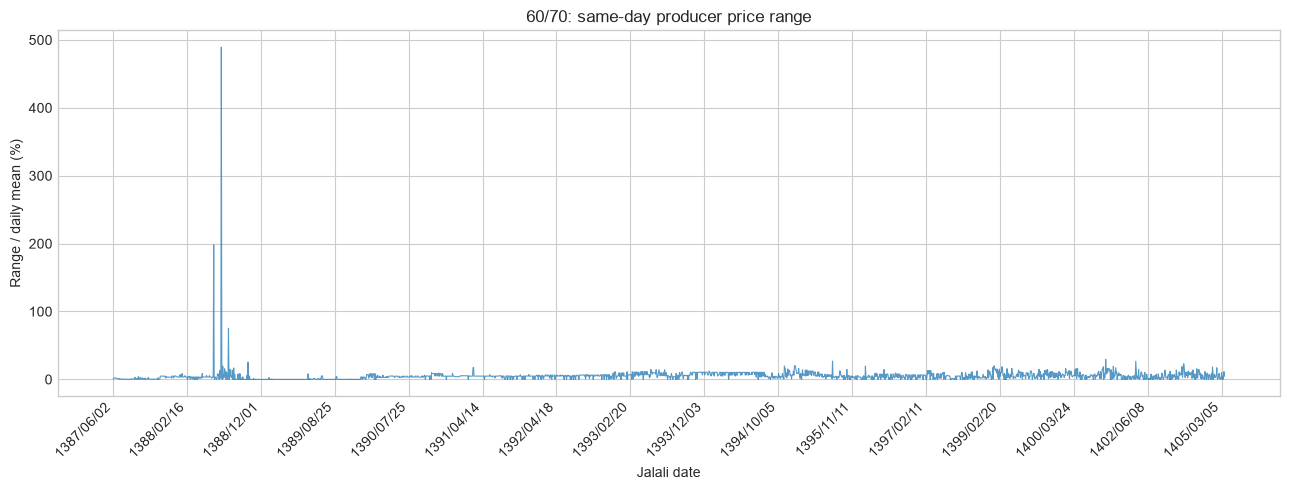

In [10]:
focus = trades.loc[(trades['bitumen_family'] == 'penetration_or_numeric') & (trades['grade'] == '6070') & (trades['market_segment'] == 'domestic_or_unspecified')].copy()
unit_currency = focus.groupby(['Currency_clean', 'Unit_clean'], dropna=False)['Quantity'].sum().sort_values(ascending=False)
primary_currency, primary_unit = unit_currency.index[0]
focus = focus.loc[(focus['Currency_clean'] == primary_currency) & (focus['Unit_clean'] == primary_unit)].copy()
focus['implied_price'] = focus['TotalPrice'] / focus['Quantity']
print(f'Primary scope: currency={primary_currency}, unit={primary_unit}')
print(f"Rows={len(focus):,} | volume={focus['Quantity'].sum():,.0f} | days={focus['jalali_date'].nunique():,} | producers={focus['ProducerName_clean'].nunique()} | {focus['jalali_date'].min()}..{focus['jalali_date'].max()}")
display(unit_currency.to_frame('volume'))

def concurrent_dispersion(frame, keys):
    pm = frame.groupby(keys + ['ProducerName_clean'], dropna=False).agg(volume=('Quantity', 'sum'), value=('TotalPrice', 'sum')).reset_index()
    pm['weighted_price'] = pm['value'] / pm['volume']
    out = pm.groupby(keys, dropna=False).agg(producers=('ProducerName_clean', 'nunique'), mean_price=('weighted_price', 'mean'), std_price=('weighted_price', 'std'), min_price=('weighted_price', 'min'), max_price=('weighted_price', 'max'), volume=('volume', 'sum')).reset_index()
    out = out.loc[out['producers'].ge(2)].copy()
    out['cv'] = out['std_price'] / out['mean_price']
    out['range_pct'] = (out['max_price'] - out['min_price']) / out['mean_price']
    return out

daily_6070 = concurrent_dispersion(focus, ['jalali_date'])
daily_contract_6070 = concurrent_dispersion(focus, ['jalali_date', 'ContractType_clean'])
recent_6070 = daily_6070.loc[daily_6070['jalali_date'].ge('1404/01/01')]
summary_6070 = pd.DataFrame({
    'all_same_day': daily_6070[['cv', 'range_pct']].quantile([.25, .5, .75, .9, .95]).stack(),
    'same_day_and_contract': daily_contract_6070[['cv', 'range_pct']].quantile([.25, .5, .75, .9, .95]).stack(),
    'same_day_since_1404': recent_6070[['cv', 'range_pct']].quantile([.25, .5, .75, .9, .95]).stack(),
})
summary_6070.index.names = ['quantile', 'metric']
display(summary_6070)
print(f'Comparable days: all={len(daily_6070):,}, since 1404={len(recent_6070):,}; comparable day-contract groups={len(daily_contract_6070):,}')
display(recent_6070.sort_values('range_pct', ascending=False).head(15))

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(daily_6070['jalali_date'], daily_6070['range_pct'] * 100, linewidth=.8, alpha=.75)
step = max(1, len(daily_6070) // 15); ticks = list(range(0, len(daily_6070), step))
ax.set_xticks(ticks, labels=daily_6070.iloc[ticks]['jalali_date'], rotation=45, ha='right')
ax.set(title='60/70: same-day producer price range', ylabel='Range / daily mean (%)', xlabel='Jalali date')
plt.tight_layout(); plt.show()

### Symbol-level comparison: cash contract and cash settlement

This comparison requires both a cash contract (`ContractType`) and observed cash settlement (`Tasvieh`). Each symbol's daily price is calculated as traded value divided by traded volume. Only dates with at least two concurrently traded symbols are compared.

In [11]:
cash_label = 'نقدی'
cash_cash = focus.loc[(focus['ContractType_clean'] == cash_label) & (focus['Tasvieh_clean'] == cash_label)].copy()
symbol_day = cash_cash.groupby(['jalali_date', 'Symbol_clean'], dropna=False).agg(volume=('Quantity', 'sum'), value=('TotalPrice', 'sum'), producer=('ProducerName_clean', 'first')).reset_index()
symbol_day['weighted_price'] = symbol_day['value'] / symbol_day['volume']
cash_cash_daily = symbol_day.groupby('jalali_date').agg(symbols=('Symbol_clean', 'nunique'), mean_price=('weighted_price', 'mean'), std_price=('weighted_price', 'std'), min_price=('weighted_price', 'min'), max_price=('weighted_price', 'max'), volume=('volume', 'sum')).reset_index()
cash_cash_daily = cash_cash_daily.loc[cash_cash_daily['symbols'].ge(2)].copy()
cash_cash_daily['cv'] = cash_cash_daily['std_price'] / cash_cash_daily['mean_price']
cash_cash_daily['range_pct'] = (cash_cash_daily['max_price'] - cash_cash_daily['min_price']) / cash_cash_daily['mean_price']
cash_cash_daily['max_over_min'] = cash_cash_daily['max_price'] / cash_cash_daily['min_price'] - 1
recent_cash_cash = cash_cash_daily.loc[cash_cash_daily['jalali_date'].ge('1404/01/01')]
print(f"Rows={len(cash_cash):,} | symbols={cash_cash['Symbol_clean'].nunique()} | days={cash_cash['jalali_date'].nunique()} | comparable days={len(cash_cash_daily)} | comparable since 1404={len(recent_cash_cash)}")
display(cash_cash_daily[['cv', 'range_pct', 'max_over_min']].quantile([.25, .5, .75, .9, .95, .99]))
display(recent_cash_cash.sort_values('range_pct', ascending=False))

Rows=638 | symbols=53 | days=568 | comparable days=62 | comparable since 1404=6


,cv,range_pct,max_over_min
0.25,0.01,0.02,0.02
0.50,0.03,0.05,0.05
0.75,0.05,0.07,0.08
0.90,0.07,0.11,0.12
0.95,0.10,0.14,0.15
0.99,0.14,0.19,0.21


,jalali_date,symbols,mean_price,std_price,min_price,max_price,volume,cv,range_pct,max_over_min
534,1404/06/18,3,"300,494.67","19,909.35","289,000.00","323,484.00",670.00,0.07,0.11,0.12
548,1404/11/05,2,"381,349.50","8,979.55","375,000.00","387,699.00",300.00,0.02,0.03,0.03
555,1405/02/08,2,"405,000.00","7,071.07","400,000.00","410,000.00",35.00,0.02,0.02,0.02
527,1404/03/12,2,"262,250.00","3,889.09","259,500.00","265,000.00",300.00,0.01,0.02,0.02
533,1404/06/09,2,"286,675.00","2,722.36","284,750.00","288,600.00",525.00,0.01,0.01,0.01
520,1404/02/14,2,"267,000.00",0.00,"267,000.00","267,000.00",810.00,0.00,0.00,0.00


## 9. Can missing settlement values be treated as cash?

This section examines domestic 60/70 observations in the cash contract group, including standard cash and cash matching. Missing `Tasvieh` values are never overwritten. We first inspect when missingness occurs. If it is confined to a legacy reporting regime, those observations may be labeled *imputed cash* in a sensitivity scenario, but they must remain distinct from observed cash settlement and results must be reported both with and without the imputation.

The price comparison uses three levels of evidence:

1. Same-day comparison, potentially across different symbols.
2. Exact same-symbol, same-day pairs—the strongest direct comparison.
3. A log-price model with date and symbol fixed effects, controlling for the daily market price level and persistent symbol-specific differences.

> The source settlement category translated as `Cash / credit` indicates a mixed option or condition and does not necessarily identify the final realized settlement method. It is therefore reported separately.

In [12]:
cash_contract = focus.loc[focus['ContractType_clean'].isin(['نقدی', 'نقدی (مچینگ)'])].copy()
cash_contract['cash_contract_subtype'] = cash_contract['ContractType_clean'].map({'نقدی': 'standard_cash', 'نقدی (مچینگ)': 'cash_matching'})
settlement_labels = {'نقدی': 'Cash', 'اعتباری': 'Credit', 'نقدی / اعتباری': 'Cash / credit'}
cash_contract['settlement_group'] = cash_contract['Tasvieh_clean'].map(settlement_labels).fillna('Not reported')
settlement_profile = (cash_contract.groupby('settlement_group', dropna=False)
                      .agg(rows=('Quantity', 'size'), volume=('Quantity', 'sum'), symbols=('Symbol_clean', 'nunique'), days=('jalali_date', 'nunique'), first_date=('jalali_date', 'min'), last_date=('jalali_date', 'max'))
                      .sort_values('volume', ascending=False))
settlement_profile['volume_share'] = settlement_profile['volume'] / settlement_profile['volume'].sum()
display(settlement_profile)

cash_contract['jalali_year_text'] = cash_contract['jalali_date'].str[:4]
missing_by_year = cash_contract.groupby('jalali_year_text').agg(total_volume=('Quantity', 'sum'), missing_volume=('Quantity', lambda s: s[cash_contract.loc[s.index, 'settlement_group'].eq('Not reported')].sum()))
missing_by_year['missing_volume_share'] = missing_by_year['missing_volume'] / missing_by_year['total_volume']
display(missing_by_year)
print('Missing settlement coverage:', cash_contract.loc[cash_contract['settlement_group'].eq('Not reported'), 'jalali_date'].min(), 'to', cash_contract.loc[cash_contract['settlement_group'].eq('Not reported'), 'jalali_date'].max())
print('Observed cash settlement begins:', cash_contract.loc[cash_contract['settlement_group'].eq('Cash'), 'jalali_date'].min())

,rows,volume,symbols,days,first_date,last_date,volume_share
settlement_group,,,,,,,
Not reported,5178,"7,536,099.50",38,1042,1387/06/02,1392/05/20,0.61
Credit,1388,"2,424,496.00",16,765,1392/05/14,1402/07/25,0.19
Cash / credit,3598,"2,271,868.00",29,1468,1392/02/31,1405/04/10,0.18
Cash,867,"215,106.00",53,672,1392/05/02,1405/05/20,0.02


,total_volume,missing_volume,missing_volume_share
jalali_year_text,,,
1387,"1,170,350.00","1,170,350.00",1.00
1388,"2,125,846.50","2,125,846.50",1.00
1389,"1,380,107.00","1,380,107.00",1.00
1390,"1,111,627.00","1,111,627.00",1.00
1391,"1,419,515.00","1,419,515.00",1.00
1392,"1,065,899.00","328,654.00",0.31
1393,"1,349,686.00",0.00,0.00
1394,"991,960.00",0.00,0.00
1395,"471,440.00",0.00,0.00


Missing settlement coverage: 1387/06/02 to 1392/05/20
Observed cash settlement begins: 1392/05/02


### Cash / credit versus cash settlement within the cash contract group

Each group's daily price is calculated as total traded value divided by total traded volume. A settlement premium is the comparison-group price divided by the cash-settlement price minus one. We first test whether the same symbol trades under two settlement conditions on the same date. Without such exact pairs, the simple comparison is not causal; the fixed-effects model provides a complementary adjusted estimate.

In [13]:
import statsmodels.formula.api as smf

settlement_codes = {'Cash': 'cash', 'Credit': 'credit', 'Cash / credit': 'mixed', 'Not reported': 'missing'}
cash_contract['settlement_code'] = cash_contract['settlement_group'].map(settlement_codes)
symbol_day_settlement = (cash_contract.groupby(['jalali_date', 'Symbol_clean', 'cash_contract_subtype', 'settlement_code'], dropna=False)
                         .agg(volume=('Quantity', 'sum'), value=('TotalPrice', 'sum')).reset_index())
symbol_day_settlement['weighted_price'] = symbol_day_settlement['value'] / symbol_day_settlement['volume']

exact_pairs = symbol_day_settlement.pivot_table(index=['jalali_date', 'Symbol_clean', 'cash_contract_subtype'], columns='settlement_code', values='weighted_price')
pair_counts = pd.Series({
    'cash_credit_exact_symbol_day_pairs': exact_pairs[['cash', 'credit']].dropna().shape[0],
    'cash_mixed_exact_symbol_day_pairs': exact_pairs[['cash', 'mixed']].dropna().shape[0],
    'cash_missing_exact_symbol_day_pairs': exact_pairs[['cash', 'missing']].dropna().shape[0],
})
display(pair_counts.to_frame('pairs'))

day_settlement = (cash_contract.groupby(['jalali_date', 'settlement_code'])
                  .agg(volume=('Quantity', 'sum'), value=('TotalPrice', 'sum')).reset_index())
day_settlement['weighted_price'] = day_settlement['value'] / day_settlement['volume']
day_prices = day_settlement.pivot(index='jalali_date', columns='settlement_code', values='weighted_price')
same_day_results = []
for comparison in ['credit', 'mixed', 'missing']:
    paired = day_prices[['cash', comparison]].dropna().copy()
    premium = paired[comparison] / paired['cash'] - 1
    same_day_results.append({'comparison': comparison, 'common_days': len(paired), 'mean_premium': premium.mean(), 'median_premium': premium.median(), 'p25': premium.quantile(.25), 'p75': premium.quantile(.75)})
display(pd.DataFrame(same_day_results).set_index('comparison'))

nonmissing_model_data = symbol_day_settlement.loc[symbol_day_settlement['settlement_code'].ne('missing')].copy()
comparison_dates = (nonmissing_model_data.groupby('jalali_date')['settlement_code'].nunique().loc[lambda s: s.ge(2)].index)
model_data = nonmissing_model_data.loc[nonmissing_model_data['jalali_date'].isin(comparison_dates)].copy()
model_data['log_price'] = np.log(model_data['weighted_price'])
formula = 'log_price ~ C(jalali_date) + C(Symbol_clean) + C(cash_contract_subtype) + C(settlement_code, Treatment(reference="cash"))'
models = {
    'unweighted': smf.ols(formula, data=model_data).fit(cov_type='cluster', cov_kwds={'groups': model_data['jalali_date']}),
    'volume_weighted': smf.wls(formula, data=model_data, weights=model_data['volume']).fit(cov_type='cluster', cov_kwds={'groups': model_data['jalali_date']}),
}
rows = []
for model_name, model in models.items():
    for comparison in ['credit', 'mixed']:
        key = f'C(settlement_code, Treatment(reference="cash"))[T.{comparison}]'
        beta, se = model.params[key], model.bse[key]
        rows.append({'model': model_name, 'comparison': comparison, 'estimated_premium': np.exp(beta)-1, 'ci95_low': np.exp(beta-1.96*se)-1, 'ci95_high': np.exp(beta+1.96*se)-1, 'p_value': model.pvalues[key]})
fixed_effect_results = pd.DataFrame(rows).set_index(['model', 'comparison'])
display(fixed_effect_results)

missing_overlap_days = day_prices[['cash', 'missing']].dropna().shape[0]
print(f'Missing versus observed-cash overlap: {missing_overlap_days} common day(s).')
print('The missing-settlement coefficient is not estimated because there is insufficient contemporaneous overlap. Retain missing values only as an imputed-cash sensitivity scenario, never as observed cash settlement.')

,pairs
cash_credit_exact_symbol_day_pairs,0
cash_mixed_exact_symbol_day_pairs,0
cash_missing_exact_symbol_day_pairs,0


,common_days,mean_premium,median_premium,p25,p75
comparison,,,,,
credit,167,-0.00,-0.00,-0.03,0.02
mixed,361,0.01,0.01,-0.01,0.05
missing,1,0.01,0.01,0.01,0.01


estimated_premium  ci95_low  ci95_high  p_value
model           comparison                                                 
unweighted      credit                   0.01     -0.00       0.02     0.20
                mixed                    0.01     -0.00       0.02     0.16
volume_weighted credit                  -0.01     -0.02       0.01     0.29
                mixed                   -0.01     -0.02       0.01     0.28

Missing versus observed-cash overlap: 1 common day(s).
The missing-settlement coefficient is not estimated because there is insufficient contemporaneous overlap. Retain missing values only as an imputed-cash sensitivity scenario, never as observed cash settlement.


## 10. Standard cash versus cash-matching contracts

This section tests whether standard cash and cash-matching transactions may be pooled into one cash benchmark group. The primary evidence uses exact same-symbol, same-day pairs. It is supplemented by date/symbol fixed-effects regressions and a recent-period check.

In [14]:
cash_matching_scope = focus.loc[focus['ContractType_clean'].isin(['نقدی', 'نقدی (مچینگ)'])].copy()
cash_matching_scope['cash_group'] = cash_matching_scope['ContractType_clean'].map({'نقدی': 'standard_cash', 'نقدی (مچینگ)': 'cash_matching'})
display(cash_matching_scope.groupby('cash_group').agg(rows=('Quantity', 'size'), volume=('Quantity', 'sum'), symbols=('Symbol_clean', 'nunique'), days=('jalali_date', 'nunique'), first_date=('jalali_date', 'min'), last_date=('jalali_date', 'max')))

symbol_day_cash = cash_matching_scope.groupby(['jalali_date', 'Symbol_clean', 'cash_group']).agg(volume=('Quantity', 'sum'), value=('TotalPrice', 'sum')).reset_index()
symbol_day_cash['weighted_price'] = symbol_day_cash['value'] / symbol_day_cash['volume']
cash_pairs = symbol_day_cash.pivot_table(index=['jalali_date', 'Symbol_clean'], columns='cash_group', values='weighted_price')[['standard_cash', 'cash_matching']].dropna()
cash_pairs['matching_premium'] = cash_pairs['cash_matching'] / cash_pairs['standard_cash'] - 1
cash_pairs['absolute_premium'] = cash_pairs['matching_premium'].abs()
pair_diagnostics = pd.Series({'exact_pairs': len(cash_pairs), 'symbols': cash_pairs.reset_index()['Symbol_clean'].nunique(), 'dates': cash_pairs.reset_index()['jalali_date'].nunique(), 'exactly_equal': cash_pairs['absolute_premium'].lt(1e-9).sum(), 'within_10_basis_points': cash_pairs['absolute_premium'].le(.001).sum(), 'within_50_basis_points': cash_pairs['absolute_premium'].le(.005).sum(), 'within_1_percent': cash_pairs['absolute_premium'].le(.01).sum()})
display(pair_diagnostics.to_frame('count'))
display(cash_pairs['matching_premium'].describe(percentiles=[.01, .10, .25, .50, .75, .90, .95, .99]).to_frame())

recent_cash_pairs = cash_pairs.loc[cash_pairs.reset_index()['jalali_date'].ge('1404/01/01').to_numpy()]
print(f"Pairs since 1404: {len(recent_cash_pairs)} | nonzero differences: {recent_cash_pairs['absolute_premium'].gt(1e-9).sum()}")

cash_comparison_dates = cash_pairs.reset_index()['jalali_date'].unique()
cash_model_data = symbol_day_cash.loc[symbol_day_cash['jalali_date'].isin(cash_comparison_dates)].copy()
cash_model_data['log_price'] = np.log(cash_model_data['weighted_price'])
cash_formula = 'log_price ~ C(jalali_date) + C(Symbol_clean) + C(cash_group, Treatment(reference="standard_cash"))'
cash_models = {'unweighted': smf.ols(cash_formula, data=cash_model_data).fit(cov_type='cluster', cov_kwds={'groups': cash_model_data['jalali_date']}), 'volume_weighted': smf.wls(cash_formula, data=cash_model_data, weights=cash_model_data['volume']).fit(cov_type='cluster', cov_kwds={'groups': cash_model_data['jalali_date']})}
cash_key = 'C(cash_group, Treatment(reference="standard_cash"))[T.cash_matching]'
cash_results = []
for model_name, model in cash_models.items():
    beta, se = model.params[cash_key], model.bse[cash_key]
    cash_results.append({'model': model_name, 'estimated_matching_premium': np.exp(beta)-1, 'ci95_low': np.exp(beta-1.96*se)-1, 'ci95_high': np.exp(beta+1.96*se)-1, 'p_value': model.pvalues[cash_key]})
display(pd.DataFrame(cash_results).set_index('model'))
print('Decision: standard cash and cash matching may be pooled for price construction, while preserving the source contract flag and reporting a cash-only sensitivity series.')

,rows,volume,symbols,days,first_date,last_date
cash_group,,,,,,
cash_matching,2668,"1,359,219.50",39,1573,1387/06/02,1405/02/29
standard_cash,8363,"11,088,350.00",90,2766,1387/06/02,1405/05/20


,count
exact_pairs,1855
symbols,33
dates,1215
exactly_equal,1786
within_10_basis_points,1815
within_50_basis_points,1841
within_1_percent,1846


,matching_premium
count,"1,855.00"
mean,0.00
std,0.00
min,-0.01
1%,-0.00
10%,0.00
25%,0.00
50%,0.00
75%,0.00
90%,0.00


Pairs since 1404: 14 | nonzero differences: 0


,estimated_matching_premium,ci95_low,ci95_high,p_value
model,,,,
unweighted,-0.00,-0.00,-0.00,0.01
volume_weighted,-0.00,-0.00,0.00,0.73


Decision: standard cash and cash matching may be pooled for price construction, while preserving the source contract flag and reporting a cash-only sensitivity series.


## 11. Cash versus credit contracts for domestic 60/70

This section compares the contract itself, independently of the `Tasvieh` settlement field. The cash group includes standard cash and cash-matching contracts; the credit group includes standard credit and credit-matching contracts. Forward contracts are excluded.

Three estimates are reported: pooled same-day prices, exact same-symbol/same-day pairs, and log-price regressions with date and symbol fixed effects. The exact-pair comparison is especially informative because it holds both the trading date and product symbol constant.

In [15]:
contract_comparison = focus.copy()
contract_comparison['contract_group'] = np.select(
    [contract_comparison['ContractType_clean'].str.startswith('نقدی', na=False), contract_comparison['ContractType_clean'].str.startswith('نسیه', na=False)],
    ['cash', 'credit'], default='excluded'
)
contract_comparison = contract_comparison.loc[contract_comparison['contract_group'].isin(['cash', 'credit'])].copy()
contract_profile = contract_comparison.groupby('contract_group').agg(rows=('Quantity', 'size'), volume=('Quantity', 'sum'), symbols=('Symbol_clean', 'nunique'), days=('jalali_date', 'nunique'), first_date=('jalali_date', 'min'), last_date=('jalali_date', 'max'))
display(contract_profile)

symbol_day_contract = contract_comparison.groupby(['jalali_date', 'Symbol_clean', 'contract_group']).agg(volume=('Quantity', 'sum'), value=('TotalPrice', 'sum')).reset_index()
symbol_day_contract['weighted_price'] = symbol_day_contract['value'] / symbol_day_contract['volume']
exact_contract_pairs = symbol_day_contract.pivot_table(index=['jalali_date', 'Symbol_clean'], columns='contract_group', values='weighted_price')[['cash', 'credit']].dropna()
exact_contract_premium = exact_contract_pairs['credit'] / exact_contract_pairs['cash'] - 1
print(f"Exact symbol-day pairs: {len(exact_contract_pairs)} | symbols: {exact_contract_pairs.reset_index()['Symbol_clean'].nunique()} | dates: {exact_contract_pairs.reset_index()['jalali_date'].nunique()}")
display(exact_contract_premium.describe(percentiles=[.10, .25, .50, .75, .90, .95, .99]).to_frame('credit_premium'))

daily_contract = contract_comparison.groupby(['jalali_date', 'contract_group']).agg(volume=('Quantity', 'sum'), value=('TotalPrice', 'sum')).reset_index()
daily_contract['weighted_price'] = daily_contract['value'] / daily_contract['volume']
daily_contract_prices = daily_contract.pivot(index='jalali_date', columns='contract_group', values='weighted_price')[['cash', 'credit']].dropna()
daily_contract_premium = daily_contract_prices['credit'] / daily_contract_prices['cash'] - 1
display(daily_contract_premium.describe(percentiles=[.10, .25, .50, .75, .90, .95, .99]).to_frame('same_day_credit_premium'))

contract_model_data = symbol_day_contract.loc[symbol_day_contract['jalali_date'].isin(daily_contract_prices.index)].copy()
contract_model_data['log_price'] = np.log(contract_model_data['weighted_price'])
contract_formula = 'log_price ~ C(jalali_date) + C(Symbol_clean) + C(contract_group, Treatment(reference="cash"))'
contract_models = {
    'unweighted': smf.ols(contract_formula, data=contract_model_data).fit(cov_type='cluster', cov_kwds={'groups': contract_model_data['jalali_date']}),
    'volume_weighted': smf.wls(contract_formula, data=contract_model_data, weights=contract_model_data['volume']).fit(cov_type='cluster', cov_kwds={'groups': contract_model_data['jalali_date']}),
}
contract_results = []
contract_key = 'C(contract_group, Treatment(reference="cash"))[T.credit]'
for model_name, model in contract_models.items():
    beta, se = model.params[contract_key], model.bse[contract_key]
    contract_results.append({'model': model_name, 'estimated_credit_premium': np.exp(beta)-1, 'ci95_low': np.exp(beta-1.96*se)-1, 'ci95_high': np.exp(beta+1.96*se)-1, 'p_value': model.pvalues[contract_key]})
display(pd.DataFrame(contract_results).set_index('model'))
print('Interpretation: credit contracts exhibit a positive and statistically significant premium and should not be pooled with cash contracts without an explicit adjustment.')

,rows,volume,symbols,days,first_date,last_date
contract_group,,,,,,
cash,11031,"12,447,569.50",92,2921,1387/06/02,1405/05/20
credit,919,"570,391.00",46,416,1387/08/12,1405/05/20


Exact symbol-day pairs: 45 | symbols: 8 | dates: 42


,credit_premium
count,45.00
mean,0.05
std,0.02
min,0.00
10%,0.05
25%,0.05
50%,0.05
75%,0.05
90%,0.06
95%,0.07


,same_day_credit_premium
count,230.00
mean,0.03
std,0.05
min,-0.18
10%,-0.03
25%,0.00
50%,0.03
75%,0.05
90%,0.07
95%,0.09


,estimated_credit_premium,ci95_low,ci95_high,p_value
model,,,,
unweighted,0.03,0.02,0.04,0.00
volume_weighted,0.03,0.03,0.04,0.00


Interpretation: credit contracts exhibit a positive and statistically significant premium and should not be pooled with cash contracts without an explicit adjustment.


## 12. Physical-market analysis from certificate inception

The earliest certificate observation is used as the analytical inception date for bubble research. This is an empirical convention and must not be described as the legally verified issuance date until an official issuance document is obtained. The window is inclusive because the certificate has positive trading volume on its first observed date.

The post-inception candidate retains conventional domestic 60/70, rial/ton observations, standard cash plus cash-matching contracts, and observed `Cash` plus `Cash / credit` settlement. Credit and forward contracts remain excluded.

In [16]:
CERTIFICATE_PATH = ROOT / 'commodity/bitumen/data/raw/certificate/bitumen_certificate_raw.csv'
certificate = pd.read_csv(CERTIFICATE_PATH, encoding='utf-8-sig', low_memory=False)
certificate['TradesVolume'] = pd.to_numeric(certificate['TradesVolume'], errors='coerce')
certificate = certificate.sort_values('DT').reset_index(drop=True)
certificate_start_gregorian = certificate.loc[0, 'DT'][:10]
certificate_start_jalali = certificate.loc[0, 'PersianDate']
assert certificate.loc[0, 'TradesVolume'] > 0
print(f'Certificate analytical inception: {certificate_start_gregorian} / {certificate_start_jalali}')

post_inception = focus.loc[focus['jalali_date'].ge(certificate_start_jalali)].copy()
post_inception['contract_group'] = np.select([post_inception['ContractType_clean'].isin(['نقدی', 'نقدی (مچینگ)']), post_inception['ContractType_clean'].str.startswith('نسیه', na=False)], ['cash_group', 'credit_group'], default='other')
post_inception['settlement_group'] = np.select([post_inception['Tasvieh_clean'].eq('نقدی'), post_inception['Tasvieh_clean'].eq('نقدی / اعتباری'), post_inception['Tasvieh_clean'].isna()], ['cash', 'cash_credit', 'not_reported'], default='other')
post_profile = pd.Series({'rows': len(post_inception), 'volume': post_inception['Quantity'].sum(), 'trading_days': post_inception['jalali_date'].nunique(), 'symbols': post_inception['Symbol_clean'].nunique(), 'producers': post_inception['ProducerName_clean'].nunique(), 'first_date': post_inception['jalali_date'].min(), 'last_date': post_inception['jalali_date'].max()})
display(post_profile.to_frame('all_60_70'))
display(post_inception.groupby('contract_group').agg(rows=('Quantity', 'size'), volume=('Quantity', 'sum'), days=('jalali_date', 'nunique'), symbols=('Symbol_clean', 'nunique')).sort_values('volume', ascending=False))
display(post_inception.groupby('settlement_group').agg(rows=('Quantity', 'size'), volume=('Quantity', 'sum'), days=('jalali_date', 'nunique'), symbols=('Symbol_clean', 'nunique')).sort_values('volume', ascending=False))

post_candidate = post_inception.loc[post_inception['contract_group'].eq('cash_group') & post_inception['settlement_group'].isin(['cash', 'cash_credit'])].copy()
candidate_profile = pd.Series({'rows': len(post_candidate), 'volume': post_candidate['Quantity'].sum(), 'trading_days': post_candidate['jalali_date'].nunique(), 'symbols': post_candidate['Symbol_clean'].nunique(), 'producers': post_candidate['ProducerName_clean'].nunique(), 'first_date': post_candidate['jalali_date'].min(), 'last_date': post_candidate['jalali_date'].max()})
display(candidate_profile.to_frame('eligible_candidate'))
post_symbols = post_candidate.groupby(['Symbol_clean', 'ProducerName_clean']).agg(rows=('Quantity', 'size'), volume=('Quantity', 'sum'), days=('jalali_date', 'nunique'), first_date=('jalali_date', 'min'), last_date=('jalali_date', 'max')).sort_values('volume', ascending=False)
post_symbols['volume_share'] = post_symbols['volume'] / post_symbols['volume'].sum()
display(post_symbols)

post_symbol_day = post_candidate.groupby(['jalali_date', 'Symbol_clean']).agg(volume=('Quantity', 'sum'), value=('TotalPrice', 'sum')).reset_index()
post_symbol_day['weighted_price'] = post_symbol_day['value'] / post_symbol_day['volume']
post_daily = post_symbol_day.groupby('jalali_date').agg(symbols=('Symbol_clean', 'nunique'), volume=('volume', 'sum'), mean_price=('weighted_price', 'mean'), std_price=('weighted_price', 'std'), min_price=('weighted_price', 'min'), max_price=('weighted_price', 'max'))
post_daily['cv'] = post_daily['std_price'] / post_daily['mean_price']
post_daily['range_pct'] = (post_daily['max_price'] - post_daily['min_price']) / post_daily['mean_price']
display(post_daily[['symbols', 'volume']].describe(percentiles=[.25, .50, .75, .90, .95]))
display(post_daily.loc[post_daily['symbols'].ge(2), ['symbols', 'cv', 'range_pct']].describe(percentiles=[.25, .50, .75, .90, .95]))

certificate_dates = set(certificate['PersianDate'].astype(str))
positive_certificate_dates = set(certificate.loc[certificate['TradesVolume'].gt(0), 'PersianDate'].astype(str))
physical_dates = set(post_candidate['jalali_date'].astype(str))
overlap = pd.Series({'certificate_calendar_observations': len(certificate_dates), 'positive_certificate_days': len(positive_certificate_dates), 'physical_candidate_days': len(physical_dates), 'all_certificate_exact_date_overlap': len(certificate_dates & physical_dates), 'positive_certificate_exact_date_overlap': len(positive_certificate_dates & physical_dates)})
display(overlap.to_frame('days'))
print('Implication: an exact-date daily bubble would be sparse. Benchmark carry-forward, temporal matching, or lower-frequency aggregation requires an explicit rule and sensitivity analysis.')

Certificate analytical inception: 2025-10-20 / 1404/07/28


,all_60_70
rows,158
volume,"153,075.00"
trading_days,83
symbols,29
producers,30
first_date,1404/07/28
last_date,1405/05/20


,rows,volume,days,symbols
contract_group,,,,
credit_group,51,"68,065.00",41,15
other,28,"59,600.00",19,1
cash_group,79,"25,410.00",51,18


,rows,volume,days,symbols
settlement_group,,,,
cash_credit,124,"146,470.00",70,25
cash,34,"6,605.00",30,10


,eligible_candidate
rows,79
volume,"25,410.00"
trading_days,51
symbols,18
producers,19
first_date,1404/08/04
last_date,1405/05/20


,,rows,volume,days,first_date,last_date,volume_share
Symbol_clean,ProducerName_clean,,,,,,
PAC-BI6070B-00,نفت پاسارگاد تهران,13,"6,475.00",11,1404/11/07,1405/03/05,0.25
PACR-BI6070B-00,نفت پاسارگاد اراک,11,"4,550.00",8,1404/08/12,1404/12/23,0.18
PACT-BI6070B-00,نفت پاسارگاد تبریز,3,"3,000.00",2,1404/10/21,1404/11/11,0.12
PACS-BI6070B-00,نفت پاسارگاد شیراز,5,"2,500.00",3,1404/08/12,1404/11/07,0.10
PBDJ-BI6070B-00,پالایش قیر پارمیس دلیجان (عایق رطوبتی پارمیس بام دلیجان),6,"1,800.00",6,1404/12/23,1405/05/20,0.07
NFSH-BI6070B-00,نگین فخر شیراز,9,"1,735.00",9,1404/08/04,1405/04/28,0.07
PACB-BI6070B-00,نفت پاسارگاد بندرعباس,3,"1,225.00",3,1404/08/13,1405/02/15,0.05
ALMA-BI6070B-00,تولیدی الماس قیر دلیجان,4,900.00,4,1404/11/21,1405/03/02,0.04
DBG-BI6070B-00,پالایش دنا بام گلستان,2,840.00,2,1404/10/06,1405/05/06,0.03


,symbols,volume
count,51.00,51.00
mean,1.35,498.24
std,0.66,555.59
min,1.00,25.00
25%,1.00,150.00
50%,1.00,300.00
75%,1.50,587.50
90%,2.00,"1,050.00"
95%,3.00,"1,795.00"
max,3.00,"2,450.00"


,symbols,cv,range_pct
count,13.00,13.00,13.00
mean,2.38,0.03,0.06
std,0.51,0.02,0.04
min,2.00,0.00,0.00
25%,2.00,0.02,0.03
50%,2.00,0.03,0.05
75%,3.00,0.04,0.07
90%,3.00,0.07,0.10
95%,3.00,0.08,0.13
max,3.00,0.09,0.17


,days
certificate_calendar_observations,257
positive_certificate_days,185
physical_candidate_days,51
all_certificate_exact_date_overlap,51
positive_certificate_exact_date_overlap,50


Implication: an exact-date daily bubble would be sparse. Benchmark carry-forward, temporal matching, or lower-frequency aggregation requires an explicit rule and sensitivity analysis.


## 13. Strict cash–cash exact-date bubble diagnostic

This specification uses the narrowest observable physical benchmark: conventional domestic 60/70, rial/ton, standard cash `ContractType`, observed cash `Tasvieh`, positive trades, and dates on or after certificate inception. It retains only dates when both the physical market and certificate have positive trades.

The underlying product is treated as 60/70 bitumen. The physical benchmark is fixed to domestic conventional 60/70, standard cash `ContractType`, and observed cash `Tasvieh`; exports, cash-matching, cash/credit settlement, credit, and forward contracts are excluded from this strict specification.

Daily physical prices are reported as volume-weighted prices and symbol medians. Following the copper-project convention, the absolute diagnostic spread is `certificate settlement price − physical VWAP`, and the percentage spread is `100 × (certificate settlement price / physical VWAP − 1)`. Each common-date row reports both physical and certificate traded volume. The source's physical `Unit = ton` describes traded quantity and does not, by itself, establish the quotation unit of `Price`. A published market report states that each bitumen certificate represents one kilogram; the volume comparison therefore converts certificate volume to metric tons as `TradesVolume / 1,000` ([Atlas Eqtesad, 2025](https://atlaseqtesad.ir/86480/commodity-certificate-bourse-trading.html)). This is secondary evidence and must be reconciled with the official IME admission or opening notice before production use. Delivery basis, packaging, taxes, storage, and fees also remain possible basis differences.

,strict_cash
rows,32
volume,"6,480.00"
physical_days,30
symbols,10
producers,11
first_date,1404/08/04
last_date,1405/05/20


Physical records on common positive-trading dates: 31 rows across 29 dates


,jalali_date,Symbol_clean,ProducerName_clean,Quantity,Price,TotalPrice,ContractType_clean,Tasvieh_clean,TodaySettlementPrice,TradesVolume
0,1404/08/04,NFSH-BI6070B-00,نگین فخر شیراز,310.00,"294,851.00","91,403,810.00",نقدی,نقدی,"264,189.00",1147
1,1404/08/05,PBDJ-BI6070B-00,پارمیس بام دلیجان (عایق رطوبتی پارمیس بام دلیجان),200.00,"265,000.00","53,000,000.00",نقدی,نقدی,"253,394.00",573
2,1404/08/12,PPZ-BI6070B-00,پترو پالایش خورشید زاگرس,25.00,"259,875.00","6,496,875.00",نقدی,نقدی,"252,549.00",35
3,1404/08/13,AHM-BI6070B-00,پالایش حصار مهران,50.00,"275,886.00","13,794,300.00",نقدی,نقدی,"263,314.00",52
4,1404/08/18,PPZ-BI6070B-00,پترو پالایش خورشید زاگرس,25.00,"269,354.00","6,733,850.00",نقدی,نقدی,"258,349.00",4345
5,1404/08/24,PBDJ-BI6070B-00,پارمیس بام دلیجان (عایق رطوبتی پارمیس بام دلیجان),50.00,"270,000.00","13,500,000.00",نقدی,نقدی,"264,536.00",37
6,1404/09/11,MABI-BI6070B-00,پالایش قیر ماندگار,250.00,"276,000.00","69,000,000.00",نقدی,نقدی,"274,979.00",1204
7,1404/09/23,NFSH-BI6070B-00,نگین فخر شیراز,350.00,"320,199.00","112,069,650.00",نقدی,نقدی,"271,439.00",648
8,1404/10/06,DBG-BI6070B-00,پالایش دنا بام گلستان,530.00,"269,459.00","142,813,270.00",نقدی,نقدی,"259,834.00",8818
9,1404/10/30,NFSH-BI6070B-00,نگین فخر شیراز,50.00,"374,999.00","18,749,950.00",نقدی,نقدی,"361,158.00",84817


Strict physical days: 30 | positive certificate overlaps: 29


,jalali_date,symbols,physical_volume,TradesVolume,physical_vwap,median_symbol_price,TodaySettlementPrice,certificate_bubble_price_units,certificate_bubble_pct,median_benchmark_bubble_pct
0,1404/08/04,1,310.00,1147,"294,851.00","294,851.00","264,189.00","-30,662.00",-10.40,-10.40
1,1404/08/05,1,200.00,573,"265,000.00","265,000.00","253,394.00","-11,606.00",-4.38,-4.38
2,1404/08/12,1,25.00,35,"259,875.00","259,875.00","252,549.00","-7,326.00",-2.82,-2.82
3,1404/08/13,1,50.00,52,"275,886.00","275,886.00","263,314.00","-12,572.00",-4.56,-4.56
4,1404/08/18,1,25.00,4345,"269,354.00","269,354.00","258,349.00","-11,005.00",-4.09,-4.09
5,1404/08/24,1,50.00,37,"270,000.00","270,000.00","264,536.00","-5,464.00",-2.02,-2.02
6,1404/09/11,1,250.00,1204,"276,000.00","276,000.00","274,979.00","-1,021.00",-0.37,-0.37
7,1404/09/23,1,350.00,648,"320,199.00","320,199.00","271,439.00","-48,760.00",-15.23,-15.23
8,1404/10/06,1,530.00,8818,"269,459.00","269,459.00","259,834.00","-9,625.00",-3.57,-3.57
9,1404/10/30,1,50.00,84817,"374,999.00","374,999.00","361,158.00","-13,841.00",-3.69,-3.69


,certificate_bubble_pct,median_benchmark_bubble_pct
count,29.00,29.00
mean,67.49,67.51
std,87.02,87.05
min,-24.59,-24.59
10%,-15.22,-15.32
25%,-4.56,-4.56
50%,-0.37,-0.37
75%,154.93,154.93
90%,188.52,188.52
max,241.53,241.53


,jalali_date,symbols,physical_volume,min_symbol_price,max_symbol_price,physical_vwap,median_symbol_price,supplier_max_over_min_pct,supplier_range_over_mean_pct,vwap_vs_median_pct,certificate_bubble_pct,median_benchmark_bubble_pct,bubble_method_difference_pp
10,1404/11/05,2,300.00,"375,000.00","387,699.00","379,233.00","381,349.50",3.39,3.33,-0.56,-15.22,-15.69,0.47
16,1405/02/08,2,35.00,"400,000.00","410,000.00","407,142.86","405,000.00",2.50,2.47,0.53,93.87,94.90,-1.03


,overlap_days,median_certificate_price,median_physical_vwap,median_bubble_pct,min_bubble_pct,max_bubble_pct
jalali_year,,,,,,
1404,15,"271,439.00","294,851.00",-4.56,-24.59,-0.37
1405,14,"1,118,781.50","415,500.00",156.66,47.29,241.53


,n_days,mean_spread_pct,median_spread_pct,positive_days,t_test_p_value,wilcoxon_p_value,sign_test_p_value
jalali_year,,,,,,,
1404,15,-8.24,-4.56,0,0.00,0.00,0.00
1405,14,148.62,156.66,14,0.00,0.00,0.00


Exploratory 1404-versus-1405 Mann–Whitney p-value: 5.09703e-06
Inference caveat: the year split is descriptive and observations may be serially dependent; p-values are supplementary to economic and contract-specification validation.


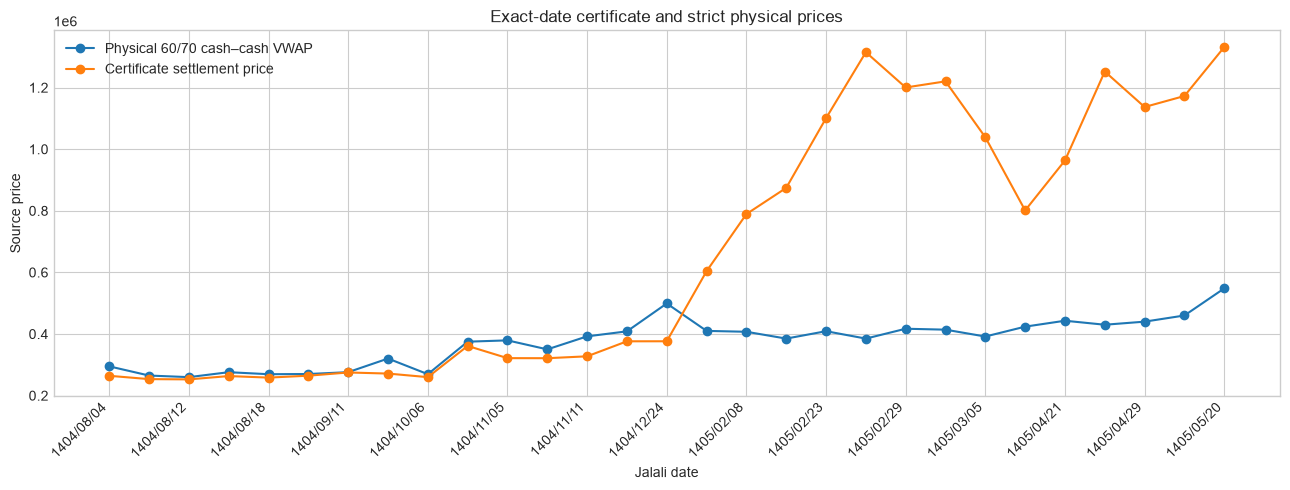

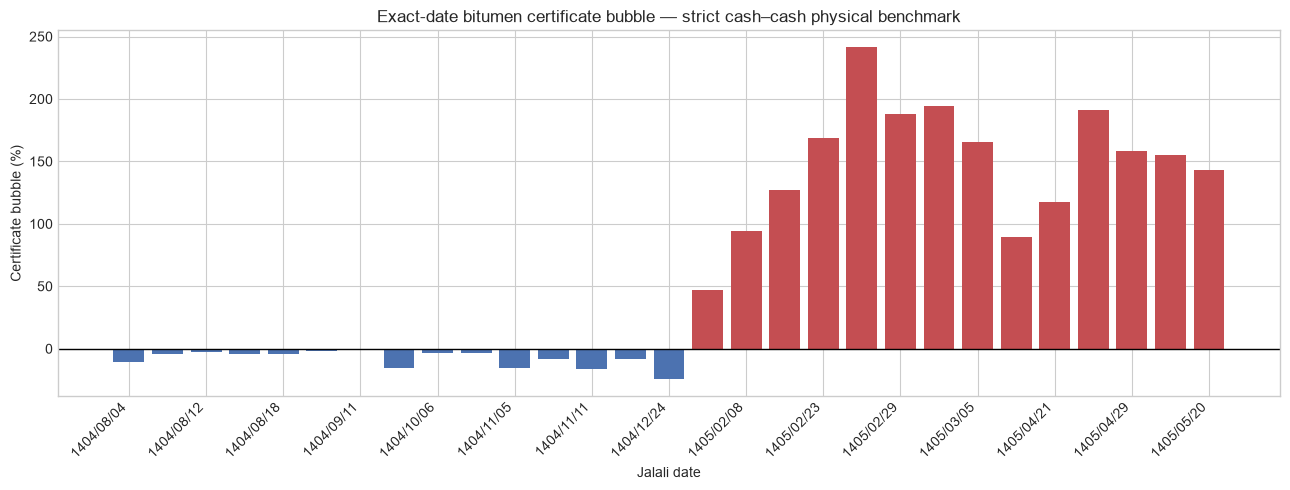

,dataset,quantity_unit_in_source,median_value_identity_ratio,maximum_absolute_identity_error
0,physical strict common-day records,ton,1.00,0.00
1,certificate positive-trading records,certificate units,1.00,0.00


Interpretation: the physical Unit field describes Quantity. TotalPrice = Quantity × Price numerically, while certificate TradesValue = TradesVolume × settlement price. Therefore value fields must not be compared directly. Price comparability additionally requires the certificate specification (certificate mass and quotation convention). A ton-versus-kilogram error would be approximately 1,000×, not the observed 1.5–3.4× divergence.


,jalali_date,physical_volume,TradesVolume,certificate_volume_tons
0,1404/08/04,310.00,1147,1.15
1,1404/08/05,200.00,573,0.57
2,1404/08/12,25.00,35,0.04
3,1404/08/13,50.00,52,0.05
4,1404/08/18,25.00,4345,4.34
5,1404/08/24,50.00,37,0.04
6,1404/09/11,250.00,1204,1.20
7,1404/09/23,350.00,648,0.65
8,1404/10/06,530.00,8818,8.82
9,1404/10/30,50.00,84817,84.82


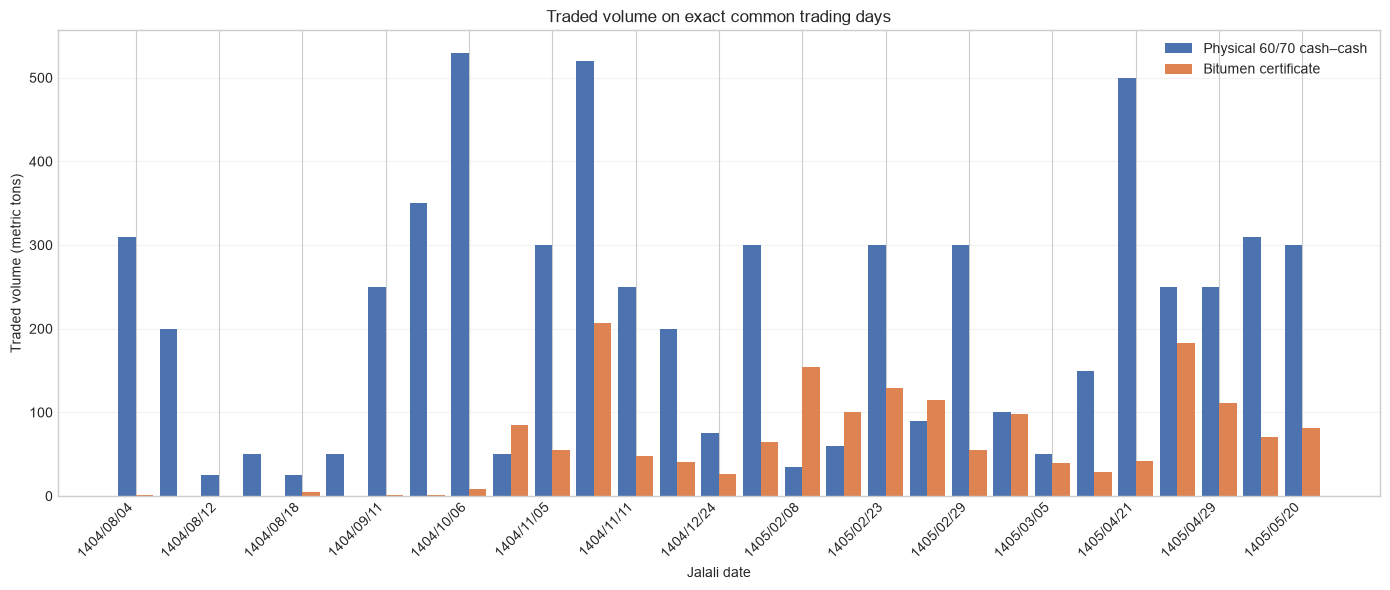

Diagnostic warning: product selection is fixed to domestic 60/70, standard cash ContractType, and observed cash Tasvieh. The sharp divergence around 1405/01 still requires official quotation-unit and contract-specification confirmation before economic interpretation as a bubble.


In [17]:
strict_cash = focus.loc[focus['jalali_date'].ge(certificate_start_jalali) & focus['ContractType_clean'].eq('نقدی') & focus['Tasvieh_clean'].eq('نقدی')].copy()
strict_profile = pd.Series({'rows': len(strict_cash), 'volume': strict_cash['Quantity'].sum(), 'physical_days': strict_cash['jalali_date'].nunique(), 'symbols': strict_cash['Symbol_clean'].nunique(), 'producers': strict_cash['ProducerName_clean'].nunique(), 'first_date': strict_cash['jalali_date'].min(), 'last_date': strict_cash['jalali_date'].max()})
display(strict_profile.to_frame('strict_cash'))

strict_symbol_day = strict_cash.groupby(['jalali_date', 'Symbol_clean']).agg(symbol_volume=('Quantity', 'sum'), symbol_value=('TotalPrice', 'sum'), producer=('ProducerName_clean', 'first')).reset_index()
strict_symbol_day['symbol_price'] = strict_symbol_day['symbol_value'] / strict_symbol_day['symbol_volume']
strict_daily = strict_symbol_day.groupby('jalali_date').agg(symbols=('Symbol_clean', 'nunique'), physical_volume=('symbol_volume', 'sum'), physical_value=('symbol_value', 'sum'), median_symbol_price=('symbol_price', 'median'), mean_symbol_price=('symbol_price', 'mean'), min_symbol_price=('symbol_price', 'min'), max_symbol_price=('symbol_price', 'max')).reset_index()
strict_daily['physical_vwap'] = strict_daily['physical_value'] / strict_daily['physical_volume']

positive_certificate = certificate.loc[certificate['TradesVolume'].gt(0) & pd.to_numeric(certificate['TodaySettlementPrice'], errors='coerce').gt(0), ['PersianDate', 'ContractCode', 'TradesVolume', 'TodaySettlementPrice', 'LastPrice']].copy()
strict_common_records = strict_cash.merge(positive_certificate, left_on='jalali_date', right_on='PersianDate', how='inner', validate='many_to_one')
strict_common_records = strict_common_records.sort_values(['jalali_date', 'Symbol_clean']).reset_index(drop=True)
record_columns = ['jalali_date', 'Symbol_clean', 'ProducerName_clean', 'Quantity', 'Price', 'TotalPrice', 'ContractType_clean', 'Tasvieh_clean', 'TodaySettlementPrice', 'TradesVolume']
print(f"Physical records on common positive-trading dates: {len(strict_common_records)} rows across {strict_common_records['jalali_date'].nunique()} dates")
display(strict_common_records[record_columns])

strict_overlap = strict_daily.merge(positive_certificate, left_on='jalali_date', right_on='PersianDate', how='inner', validate='one_to_one')
strict_overlap['certificate_bubble_price_units'] = strict_overlap['TodaySettlementPrice'] - strict_overlap['physical_vwap']
strict_overlap['certificate_bubble_pct'] = 100 * (strict_overlap['TodaySettlementPrice'] / strict_overlap['physical_vwap'] - 1)
strict_overlap['median_benchmark_bubble_pct'] = 100 * (strict_overlap['TodaySettlementPrice'] / strict_overlap['median_symbol_price'] - 1)
print(f"Strict physical days: {len(strict_daily)} | positive certificate overlaps: {len(strict_overlap)}")
bubble_columns = ['jalali_date', 'symbols', 'physical_volume', 'TradesVolume', 'physical_vwap', 'median_symbol_price', 'TodaySettlementPrice', 'certificate_bubble_price_units', 'certificate_bubble_pct', 'median_benchmark_bubble_pct']
display(strict_overlap[bubble_columns])
display(strict_overlap[['certificate_bubble_pct', 'median_benchmark_bubble_pct']].describe(percentiles=[.10, .25, .50, .75, .90]))

multi_supplier = strict_overlap.loc[strict_overlap['symbols'].ge(2)].copy()
multi_supplier['supplier_max_over_min_pct'] = 100 * (multi_supplier['max_symbol_price'] / multi_supplier['min_symbol_price'] - 1)
multi_supplier['supplier_range_over_mean_pct'] = 100 * ((multi_supplier['max_symbol_price'] - multi_supplier['min_symbol_price']) / multi_supplier['mean_symbol_price'])
multi_supplier['vwap_vs_median_pct'] = 100 * (multi_supplier['physical_vwap'] / multi_supplier['median_symbol_price'] - 1)
multi_supplier['bubble_method_difference_pp'] = multi_supplier['certificate_bubble_pct'] - multi_supplier['median_benchmark_bubble_pct']
display(multi_supplier[['jalali_date', 'symbols', 'physical_volume', 'min_symbol_price', 'max_symbol_price', 'physical_vwap', 'median_symbol_price', 'supplier_max_over_min_pct', 'supplier_range_over_mean_pct', 'vwap_vs_median_pct', 'certificate_bubble_pct', 'median_benchmark_bubble_pct', 'bubble_method_difference_pp']])

strict_overlap['jalali_year'] = strict_overlap['jalali_date'].str[:4]
display(strict_overlap.groupby('jalali_year').agg(overlap_days=('jalali_date', 'nunique'), median_certificate_price=('TodaySettlementPrice', 'median'), median_physical_vwap=('physical_vwap', 'median'), median_bubble_pct=('certificate_bubble_pct', 'median'), min_bubble_pct=('certificate_bubble_pct', 'min'), max_bubble_pct=('certificate_bubble_pct', 'max')))

# Exploratory inference by calendar regime. These tests describe the observed exact-date sample;
# they do not establish an arbitrage opportunity or correct unresolved contract-basis differences.
inference_rows = []
for year, group in strict_overlap.groupby('jalali_year'):
    spread = group['certificate_bubble_pct'].dropna()
    t_result = stats.ttest_1samp(spread, popmean=0)
    wilcoxon_result = stats.wilcoxon(spread, alternative='two-sided')
    sign_result = stats.binomtest(int(spread.gt(0).sum()), n=len(spread), p=0.5, alternative='two-sided')
    inference_rows.append({
        'jalali_year': year,
        'n_days': len(spread),
        'mean_spread_pct': spread.mean(),
        'median_spread_pct': spread.median(),
        'positive_days': int(spread.gt(0).sum()),
        't_test_p_value': t_result.pvalue,
        'wilcoxon_p_value': wilcoxon_result.pvalue,
        'sign_test_p_value': sign_result.pvalue,
    })
regime_inference = pd.DataFrame(inference_rows).set_index('jalali_year')
display(regime_inference)
pre_1405 = strict_overlap.loc[strict_overlap['jalali_year'].eq('1404'), 'certificate_bubble_pct']
post_1405 = strict_overlap.loc[strict_overlap['jalali_year'].eq('1405'), 'certificate_bubble_pct']
regime_break_test = stats.mannwhitneyu(pre_1405, post_1405, alternative='two-sided')
print(f'Exploratory 1404-versus-1405 Mann–Whitney p-value: {regime_break_test.pvalue:.6g}')
print('Inference caveat: the year split is descriptive and observations may be serially dependent; p-values are supplementary to economic and contract-specification validation.')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(strict_overlap['jalali_date'], strict_overlap['physical_vwap'], marker='o', label='Physical 60/70 cash–cash VWAP')
ax.plot(strict_overlap['jalali_date'], strict_overlap['TodaySettlementPrice'], marker='o', label='Certificate settlement price')
step = max(1, len(strict_overlap) // 12); ticks = list(range(0, len(strict_overlap), step))
ax.set_xticks(ticks, labels=strict_overlap.iloc[ticks]['jalali_date'], rotation=45, ha='right')
ax.set(title='Exact-date certificate and strict physical prices', ylabel='Source price', xlabel='Jalali date')
ax.legend(); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(13, 5))
colors = np.where(strict_overlap['certificate_bubble_pct'].ge(0), '#C44E52', '#4C72B0')
ax.bar(strict_overlap['jalali_date'], strict_overlap['certificate_bubble_pct'], color=colors)
ax.axhline(0, color='black', linewidth=1)
step = max(1, len(strict_overlap) // 12); ticks = list(range(0, len(strict_overlap), step))
ax.set_xticks(ticks, labels=strict_overlap.iloc[ticks]['jalali_date'], rotation=45, ha='right')
ax.set(title='Exact-date bitumen certificate bubble — strict cash–cash physical benchmark', ylabel='Certificate bubble (%)', xlabel='Jalali date')
plt.tight_layout(); plt.show()
# Unit audit: distinguish quantity units from quoted-price and reported-value scales.
physical_unit_audit = strict_common_records[['Quantity', 'Price', 'TotalPrice']].dropna().copy()
physical_unit_audit['value_identity_ratio'] = physical_unit_audit['TotalPrice'] / (physical_unit_audit['Quantity'] * physical_unit_audit['Price'])
certificate_unit_audit = positive_certificate.merge(certificate[['PersianDate', 'TradesValue']], on='PersianDate', how='left', validate='one_to_one')
certificate_unit_audit = certificate_unit_audit.loc[certificate_unit_audit['TradesVolume'].gt(0)].copy()
certificate_unit_audit['value_identity_ratio'] = certificate_unit_audit['TradesValue'] / (certificate_unit_audit['TradesVolume'] * certificate_unit_audit['TodaySettlementPrice'])
unit_audit = pd.DataFrame({
    'dataset': ['physical strict common-day records', 'certificate positive-trading records'],
    'quantity_unit_in_source': ['ton', 'certificate units'],
    'median_value_identity_ratio': [physical_unit_audit['value_identity_ratio'].median(), certificate_unit_audit['value_identity_ratio'].median()],
    'maximum_absolute_identity_error': [(physical_unit_audit['value_identity_ratio'] - 1).abs().max(), (certificate_unit_audit['value_identity_ratio'] - 1).abs().max()],
})
display(unit_audit)
print('Interpretation: the physical Unit field describes Quantity. TotalPrice = Quantity × Price numerically, while certificate TradesValue = TradesVolume × settlement price. Therefore value fields must not be compared directly. Price comparability additionally requires the certificate specification (certificate mass and quotation convention). A ton-versus-kilogram error would be approximately 1,000×, not the observed 1.5–3.4× divergence.')

# Common-day traded volumes converted to one unit: metric tons.
# Contract-size assumption: one bitumen certificate represents one kilogram.
KG_PER_CERTIFICATE = 1.0
KG_PER_METRIC_TON = 1_000.0
volume_plot = strict_overlap.sort_values('jalali_date').reset_index(drop=True).copy()
volume_plot['certificate_volume_tons'] = volume_plot['TradesVolume'] * KG_PER_CERTIFICATE / KG_PER_METRIC_TON
assert volume_plot[['physical_volume', 'certificate_volume_tons']].ge(0).all().all()
display(volume_plot[['jalali_date', 'physical_volume', 'TradesVolume', 'certificate_volume_tons']])
x = np.arange(len(volume_plot))
width = 0.42
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width / 2, volume_plot['physical_volume'], width=width, color='#4C72B0', label='Physical 60/70 cash–cash')
ax.bar(x + width / 2, volume_plot['certificate_volume_tons'], width=width, color='#DD8452', label='Bitumen certificate')
step = max(1, len(volume_plot) // 12)
ticks = np.arange(0, len(volume_plot), step)
ax.set_xticks(ticks, labels=volume_plot.loc[ticks, 'jalali_date'], rotation=45, ha='right')
ax.set(title='Traded volume on exact common trading days', ylabel='Traded volume (metric tons)', xlabel='Jalali date')
ax.grid(axis='y', alpha=0.25)
ax.legend()
plt.tight_layout(); plt.show()
print('Diagnostic warning: product selection is fixed to domestic 60/70, standard cash ContractType, and observed cash Tasvieh. The sharp divergence around 1405/01 still requires official quotation-unit and contract-specification confirmation before economic interpretation as a bubble.')

## 14. Open questions for the physical benchmark and bubble

The next session should evaluate two competing approaches without treating either as approved in advance:

1. **Gap-adjusted reconstruction:** estimate the time-varying gap between observed `Cash` and `Cash / credit` settlement prices after certificate inception, then reconstruct a cash-equivalent price as `cash_equivalent = cash_credit_price + moving_average_gap`. Required decisions include the pairing frequency, signed gap definition, moving-average window, minimum overlap, stale-gap limit, outlier treatment, and prevention of look-ahead bias.
2. **Observed-cash-only bubble:** ignore `Cash / credit` observations and calculate the certificate bubble only on dates with eligible observed-cash physical trades. This is cleaner but produces a smaller and potentially selected sample.

Required comparison: coverage, gap stability, out-of-sample reconstruction error, sensitivity to window length, price staleness, and resulting certificate premium/discount under both approaches. The exact-date observed-cash-only series should serve as the conservative reference specification.

## 15. Research decisions and next steps

1. Review unresolved taxonomy cases and correct misclassified product labels.
2. Validate producer–supplier relationships; do not consolidate aliases without supporting evidence.
3. Keep domestic and export markets separate unless commercial comparability is demonstrated.
4. Treat cash and cash-matching contracts as initial candidates; do not combine forward or credit contracts without explicit financing and maturity adjustments.
5. Obtain the official certificate specification, unit, packaging, delivery location, and eligible producers.
6. Construct a processed basket or benchmark only after formal comparability has been established.